# Ni-Cr Steel — ML Modeling Pipeline (Google Colab)

**5 Models:** SVR | Random Forest | XGBoost | CatBoost | GPR

**Targets:** Ra (µm) — Surface Roughness | Vb (µm) — Tool Flank Wear

**Validation:** Leave-One-Out Cross-Validation (LOO-CV)

**Metrics:** R2 | RMSE | MAE | MAPE

---

### HOW TO RUN:
1. Run **Cell 1** to install packages
2. **Runtime → Restart session**
3. **Runtime → Run all**

In [ ]:
# CELL 1 — INSTALL PACKAGES
# Run this cell first, then: Runtime → Restart session → Runtime → Run all
!pip install -q scikit-learn xgboost catboost openpyxl
print('Installation complete!')
print('Next step: Runtime -> Restart session')
print('Then: Runtime -> Run all')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.4 MB/s eta 0:00:00
Installation complete!
Next step: Runtime -> Restart session
Then: Runtime -> Run all


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.base import clone
import xgboost as xgb
from catboost import CatBoostRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 12,
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

print('All imports OK')

All imports OK


In [ ]:
# CELL 3 — UPLOAD DATA FILE
# Run this cell and select your 'Ni-Cr_steel_Ra_only.xlsx' file
from google.colab import files
print('Upload your Ni-Cr_steel_Ra_only.xlsx file:')
uploaded = files.upload()
DATA_FILE = list(uploaded.keys())[0]
print('Uploaded:', DATA_FILE)

Upload your Ni-Cr_steel_Ra_only.xlsx file:


Saving Ni-Cr_steel_Ra_only.xlsx to Ni-Cr_steel_Ra_only.xlsx
Uploaded: Ni-Cr_steel_Ra_only.xlsx


In [ ]:
# CELL 4 — LOAD DATA
df = pd.read_excel(DATA_FILE)
print('Shape:', df.shape)
print('\nGroups:')
for (ins, env), g in df.groupby(['Insert', 'Environment']):
    ins_short = 'SNMG' if 'SNMG' in ins else 'SNMM'
    print(f'  {ins_short} + {env}: {len(g)} rows | Time {g.Time_min.min()}-{g.Time_min.max()} min')
print(f'\nRa: {df.Ra_um.min():.2f} - {df.Ra_um.max():.2f} um')
print(f'Vb: {df.Vb_um.min():.0f} - {df.Vb_um.max():.0f} um')
print(f'\nNote: Cutting_speed={df.Cutting_speed_m_min.unique()} and Feed={df.Feed_mm_rev.unique()} are constants -> excluded')
df.head(10)

Shape: (49, 8)

Groups:
  SNMG + Cryogenic: 13 rows | Time 0.5-30.0 min
  SNMG + Dry: 16 rows | Time 0.5-25.0 min
  SNMM + Cryogenic: 10 rows | Time 0.5-25.0 min
  SNMM + Dry: 10 rows | Time 0.5-15.0 min

Ra: 2.70 - 6.45 um
Vb: 35 - 300 um

Note: Cutting_speed=[103] and Feed=[0.2] are constants -> excluded


,Material,Insert,Environment,Cutting_speed_m_min,Feed_mm_rev,Time_min,Ra_um,Vb_um
0,Ni-Cr steel,SNMG 120408-26 TTS,Dry,103,0.2,0.5,2.80,40
1,Ni-Cr steel,SNMG 120408-26 TTS,Dry,103,0.2,1.0,3.00,50
2,Ni-Cr steel,SNMG 120408-26 TTS,Dry,103,0.2,2.0,3.21,65
3,Ni-Cr steel,SNMG 120408-26 TTS,Dry,103,0.2,3.0,3.66,80
4,Ni-Cr steel,SNMG 120408-26 TTS,Dry,103,0.2,4.5,3.97,100
5,Ni-Cr steel,SNMG 120408-26 TTS,Dry,103,0.2,5.5,4.28,110
6,Ni-Cr steel,SNMG 120408-26 TTS,Dry,103,0.2,6.5,4.46,115
7,Ni-Cr steel,SNMG 120408-26 TTS,Dry,103,0.2,8.5,4.80,130
8,Ni-Cr steel,SNMG 120408-26 TTS,Dry,103,0.2,10.5,5.01,145
9,Ni-Cr steel,SNMG 120408-26 TTS,Dry,103,0.2,12.5,5.13,175


In [ ]:
# CELL 5 — FEATURE ENGINEERING
#
# KEY DESIGN CHOICES:
# - Cutting_speed and Feed are CONSTANTS in this dataset -> excluded (zero information)
# - Real drivers: Insert type, Environment, Time_min
# - log(Time): Taylor tool wear equation: Vb ~ C * T^n -> log(Vb) linear in log(T)
# - Interaction terms: Insert x log(Time) and Env x log(Time)
#   These capture that SNMG vs SNMM wear at DIFFERENT RATES over time
#   (not just different starting values)

def engineer_features(df):
    X = pd.DataFrame()

    # Binary encoding
    X['Insert_SNMG']      = (df['Insert'].str.startswith('SNMG')).astype(float)
    X['Env_Dry']          = (df['Environment'] == 'Dry').astype(float)

    # Nonlinear time features
    t = df['Time_min'].values
    X['Time_min']         = t
    X['log_Time']         = np.log(t)
    X['sqrt_Time']        = np.sqrt(t)
    X['Time_sq']          = t ** 2

    # Interaction: condition modifies the slope of wear/roughness curve
    X['Insert_x_logTime'] = X['Insert_SNMG'] * X['log_Time']
    X['Env_x_logTime']    = X['Env_Dry']     * X['log_Time']
    X['Insert_x_Env']     = X['Insert_SNMG'] * X['Env_Dry']

    return X

X    = engineer_features(df)
y_Ra = df['Ra_um'].values
y_Vb = df['Vb_um'].values

print(f'Feature matrix: {X.shape[0]} rows x {X.shape[1]} features')
print(f'Features: {X.columns.tolist()}')
print('\nFeatures ready')
X.describe().round(3)

Feature matrix: 49 rows x 9 features
Features: ['Insert_SNMG', 'Env_Dry', 'Time_min', 'log_Time', 'sqrt_Time', 'Time_sq', 'Insert_x_logTime', 'Env_x_logTime', 'Insert_x_Env']

Features ready


,Insert_SNMG,Env_Dry,Time_min,log_Time,sqrt_Time,Time_sq,Insert_x_logTime,Env_x_logTime,Insert_x_Env
count,49.000,49.000,49.000,49.000,49.000,49.000,49.000,49.000,49.000
mean,0.592,0.531,9.980,1.775,2.833,168.776,1.167,0.921,0.327
std,0.497,0.504,8.404,1.204,1.412,222.650,1.335,1.213,0.474
min,0.000,0.000,0.500,-0.693,0.707,0.250,-0.693,-0.693,0.000
25%,0.000,0.000,3.000,1.099,1.732,9.000,0.000,0.000,0.000
50%,1.000,1.000,8.000,2.079,2.828,64.000,0.693,0.000,0.000
75%,1.000,1.000,15.500,2.741,3.937,240.250,2.526,2.079,1.000
max,1.000,1.000,30.000,3.401,5.477,900.000,3.401,3.219,1.000


In [ ]:
# CELL 6 — DEFINE 5 MODELS

def get_models():
    models = {}

    # 1. SVR - RBF kernel, scale-sensitive -> wrapped in StandardScaler
    models['SVR'] = Pipeline([
        ('scaler', StandardScaler()),
        ('model',  SVR(kernel='rbf', C=100, epsilon=0.05, gamma='scale'))
    ])

    # 2. Random Forest - 300 trees, 60% feature subsampling
    models['Random Forest'] = RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=1,
        max_features=0.6,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    # 3. XGBoost - gradient boosted trees with regularization
    models['XGBoost'] = xgb.XGBRegressor(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        verbosity=0
    )

    # 4. CatBoost - good for small data, L2 regularization
    models['CatBoost'] = CatBoostRegressor(
        iterations=300,
        depth=4,
        learning_rate=0.05,
        l2_leaf_reg=3,
        random_seed=RANDOM_STATE,
        verbose=0
    )

    # 5. GPR - Gaussian Process, Matern 5/2 kernel + noise
    #    Best for smooth physical processes (wear progression)
    kernel = (
        C(1.0, (1e-3, 1e3))
        * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5)
        + WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-5, 1.0))
    )
    models['GPR'] = Pipeline([
        ('scaler', StandardScaler()),
        ('model',  GaussianProcessRegressor(
            kernel=kernel,
            n_restarts_optimizer=15,
            normalize_y=True,
            random_state=RANDOM_STATE
        ))
    ])

    return models

print('5 models defined:', list(get_models().keys()))

5 models defined: ['SVR', 'Random Forest', 'XGBoost', 'CatBoost', 'GPR']


In [ ]:
# CELL 7 — LOO-CV AND METRICS FUNCTIONS
#
# WHY Leave-One-Out CV:
# - Only 49 data points: LOO trains on 48 and tests on 1
# - Gives 49 independent out-of-sample predictions
# - Most unbiased error estimate for small datasets
# - Standard approach in Q1 machining ML papers

def run_loo_cv(X, y, model):
    loo   = LeaveOneOut()
    X_arr = X.values
    preds = np.zeros(len(y))
    for train_idx, test_idx in loo.split(X_arr):
        m = clone(model)
        m.fit(X_arr[train_idx], y[train_idx])
        preds[test_idx] = m.predict(X_arr[test_idx])
    return preds

def compute_metrics(y_true, y_pred):
    return {
        'R2'    : round(r2_score(y_true, y_pred), 4),
        'RMSE'  : round(np.sqrt(mean_squared_error(y_true, y_pred)), 4),
        'MAE'   : round(mean_absolute_error(y_true, y_pred), 4),
        'MAPE_%': round(np.mean(np.abs((y_true - y_pred) / y_true)) * 100, 2),
    }

print('LOO-CV and metrics functions ready')

LOO-CV and metrics functions ready


In [ ]:
# CELL 8 — RUN ALL 5 MODELS  (takes ~1-2 minutes)
results_Ra = {}
results_Vb = {}
preds_Ra   = {}
preds_Vb   = {}
MODEL_NAMES = ['SVR', 'Random Forest', 'XGBoost', 'CatBoost', 'GPR']

for target_name, y_target, res_dict, pred_dict in [
    ('Ra (um)', y_Ra, results_Ra, preds_Ra),
    ('Vb (um)', y_Vb, results_Vb, preds_Vb),
]:
    print(f'\n--- {target_name} ---')
    models = get_models()
    for model_name in MODEL_NAMES:
        print(f'  {model_name:<20} ', end='', flush=True)
        y_pred  = run_loo_cv(X, y_target, models[model_name])
        metrics = compute_metrics(y_target, y_pred)
        res_dict[model_name]  = metrics
        pred_dict[model_name] = y_pred
        print(f'R2={metrics["R2"]:.4f}  RMSE={metrics["RMSE"]:.4f}  MAPE={metrics["MAPE_%"]:.2f}%')

print('\nAll models done!')


--- Ra (um) ---
  SVR                  R2=0.9813  RMSE=0.1449  MAPE=2.10%
  Random Forest        R2=0.9298  RMSE=0.2810  MAPE=4.96%
  XGBoost              R2=0.9680  RMSE=0.1898  MAPE=3.48%
  CatBoost             R2=0.9763  RMSE=0.1632  MAPE=2.44%
  GPR                  R2=0.9928  RMSE=0.0902  MAPE=1.67%

--- Vb (um) ---
  SVR                  R2=0.9594  RMSE=14.2942  MAPE=6.63%
  Random Forest        R2=0.8872  RMSE=23.8217  MAPE=16.18%
  XGBoost              R2=0.9576  RMSE=14.5944  MAPE=9.71%
  CatBoost             R2=0.9695  RMSE=12.3932  MAPE=7.39%
  GPR                  R2=0.9931  RMSE=5.8909  MAPE=4.23%

All models done!


In [ ]:
# CELL 9 — RESULTS TABLES
print('=' * 60)
print('  RESULTS SUMMARY - Ni-Cr Steel (LOO-CV)')
print('=' * 60)

for label, res in [('Ra - Surface Roughness (um)', results_Ra),
                   ('Vb - Tool Flank Wear (um)',   results_Vb)]:
    df_res = pd.DataFrame(res).T
    df_res.columns = ['R2', 'RMSE', 'MAE', 'MAPE (%)']
    df_res = df_res.sort_values('R2', ascending=False)
    df_res.index.name = 'Model'
    print(f'\n{label}:')
    display(df_res)

best_Ra = max(results_Ra, key=lambda m: results_Ra[m]['R2'])
best_Vb = max(results_Vb, key=lambda m: results_Vb[m]['R2'])
print(f'\nBest model for Ra: {best_Ra}  (R2 = {results_Ra[best_Ra]["R2"]:.4f})')
print(f'Best model for Vb: {best_Vb}  (R2 = {results_Vb[best_Vb]["R2"]:.4f})')

  RESULTS SUMMARY - Ni-Cr Steel (LOO-CV)

Ra - Surface Roughness (um):


,R2,RMSE,MAE,MAPE (%)
Model,,,,
GPR,0.9928,0.0902,0.0713,1.67
SVR,0.9813,0.1449,0.0914,2.10
CatBoost,0.9763,0.1632,0.1130,2.44
XGBoost,0.9680,0.1898,0.1577,3.48
Random Forest,0.9298,0.2810,0.2206,4.96



Vb - Tool Flank Wear (um):


,R2,RMSE,MAE,MAPE (%)
Model,,,,
GPR,0.9931,5.8909,4.8461,4.23
CatBoost,0.9695,12.3932,8.9203,7.39
SVR,0.9594,14.2942,8.6068,6.63
XGBoost,0.9576,14.5944,11.5528,9.71
Random Forest,0.8872,23.8217,18.7201,16.18



Best model for Ra: GPR  (R2 = 0.9928)
Best model for Vb: GPR  (R2 = 0.9931)


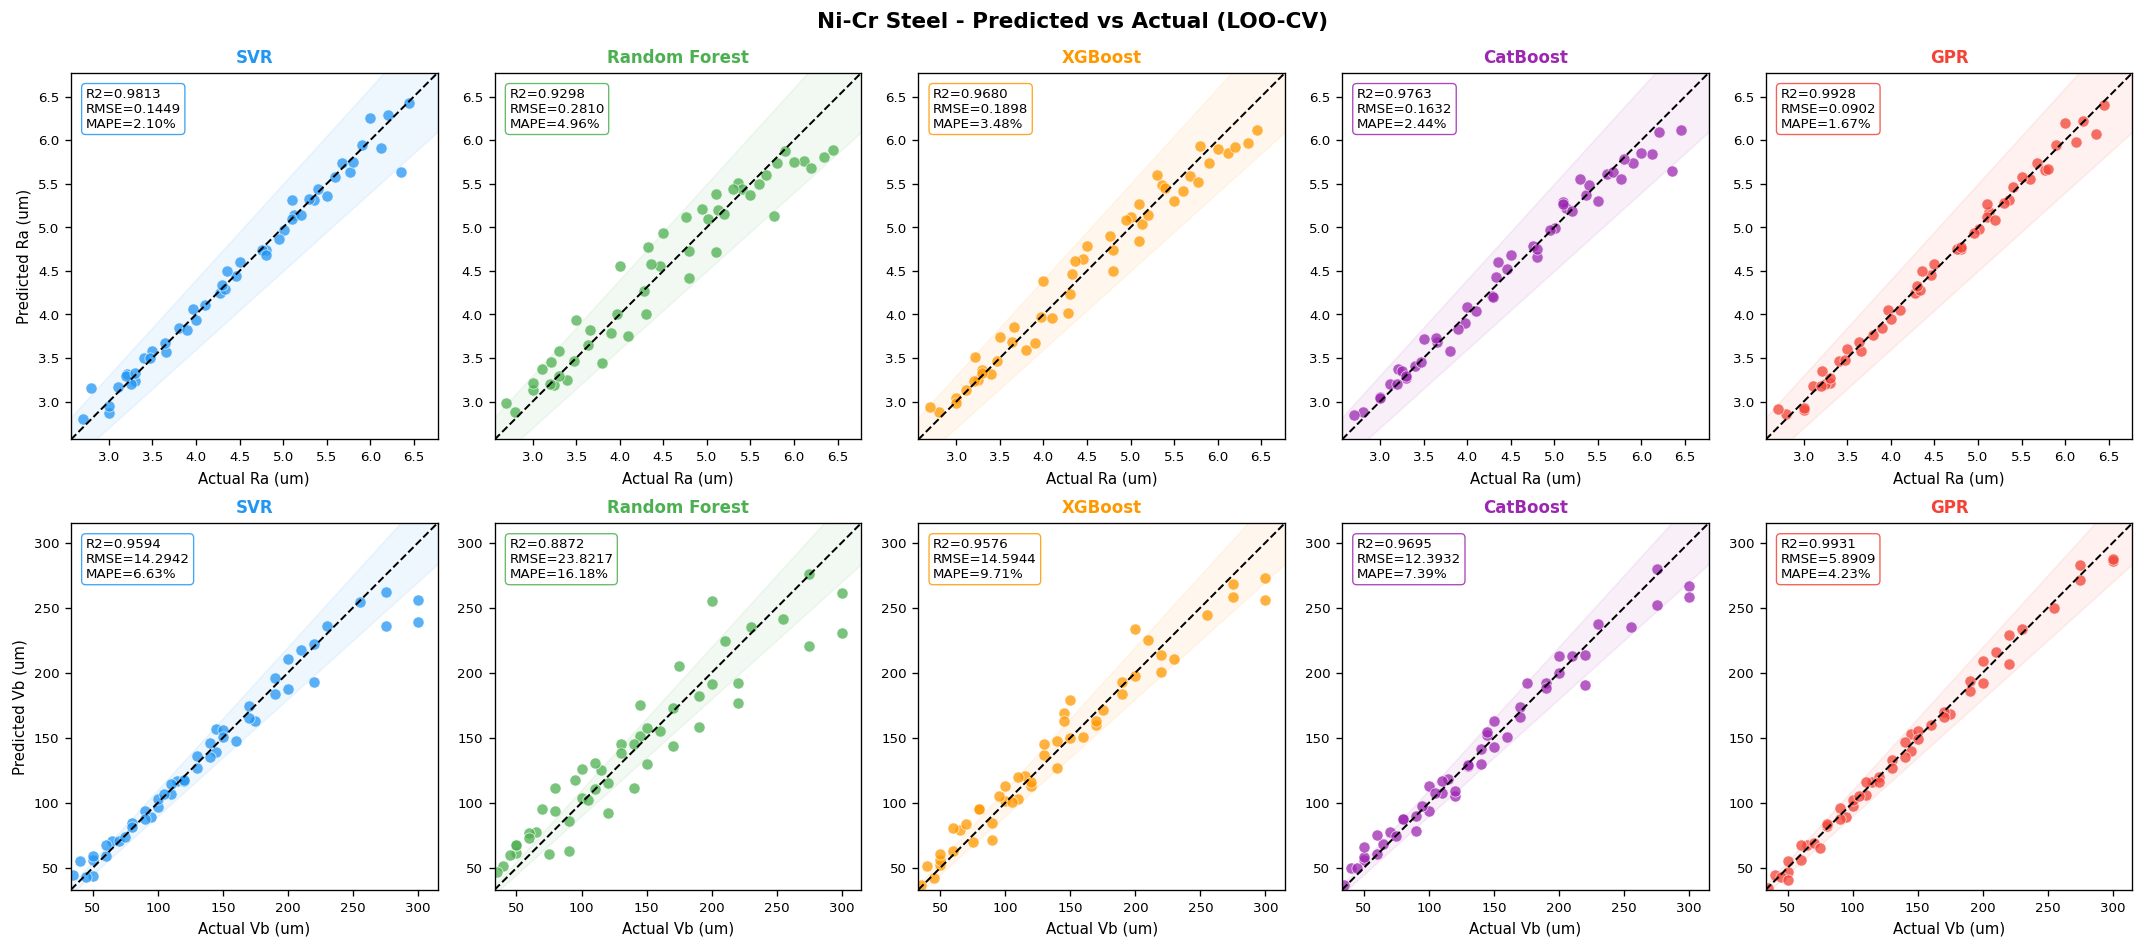

Saved: NiCr_PredVsActual.png


In [ ]:
# CELL 10 — PREDICTED vs ACTUAL PLOTS
COLORS = {
    'SVR':           '#2196F3',
    'Random Forest': '#4CAF50',
    'XGBoost':       '#FF9800',
    'CatBoost':      '#9C27B0',
    'GPR':           '#F44336',
}

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle('Ni-Cr Steel - Predicted vs Actual (LOO-CV)', fontsize=13, fontweight='bold')

for row_idx, (y_true, preds_dict, unit) in enumerate([
    (y_Ra, preds_Ra, 'Ra (um)'),
    (y_Vb, preds_Vb, 'Vb (um)'),
]):
    y_min = y_true.min() * 0.95
    y_max = y_true.max() * 1.05
    for col_idx, mname in enumerate(MODEL_NAMES):
        ax    = axes[row_idx, col_idx]
        yp    = preds_dict[mname]
        m     = (results_Ra if row_idx == 0 else results_Vb)[mname]
        color = COLORS[mname]
        ax.scatter(y_true, yp, color=color, alpha=0.75, s=45, edgecolors='white', linewidths=0.5)
        ax.plot([y_min, y_max], [y_min, y_max], 'k--', lw=1.2)
        ax.fill_between([y_min, y_max], [y_min*0.9, y_max*0.9],
                        [y_min*1.1, y_max*1.1], alpha=0.07, color=color)
        ax.set_xlim(y_min, y_max)
        ax.set_ylim(y_min, y_max)
        ax.set_xlabel(f'Actual {unit}', fontsize=9)
        if col_idx == 0:
            ax.set_ylabel(f'Predicted {unit}', fontsize=9)
        ax.set_title(mname, fontsize=10, color=color, fontweight='bold')
        ax.text(0.04, 0.96,
                f"R2={m['R2']:.4f}\nRMSE={m['RMSE']:.4f}\nMAPE={m['MAPE_%']:.2f}%",
                transform=ax.transAxes, fontsize=8, va='top',
                bbox=dict(boxstyle='round', fc='white', alpha=0.85, ec=color, lw=0.8))
        ax.set_aspect('equal', adjustable='box')
        ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig('NiCr_PredVsActual.png', dpi=300)
plt.show()
print('Saved: NiCr_PredVsActual.png')

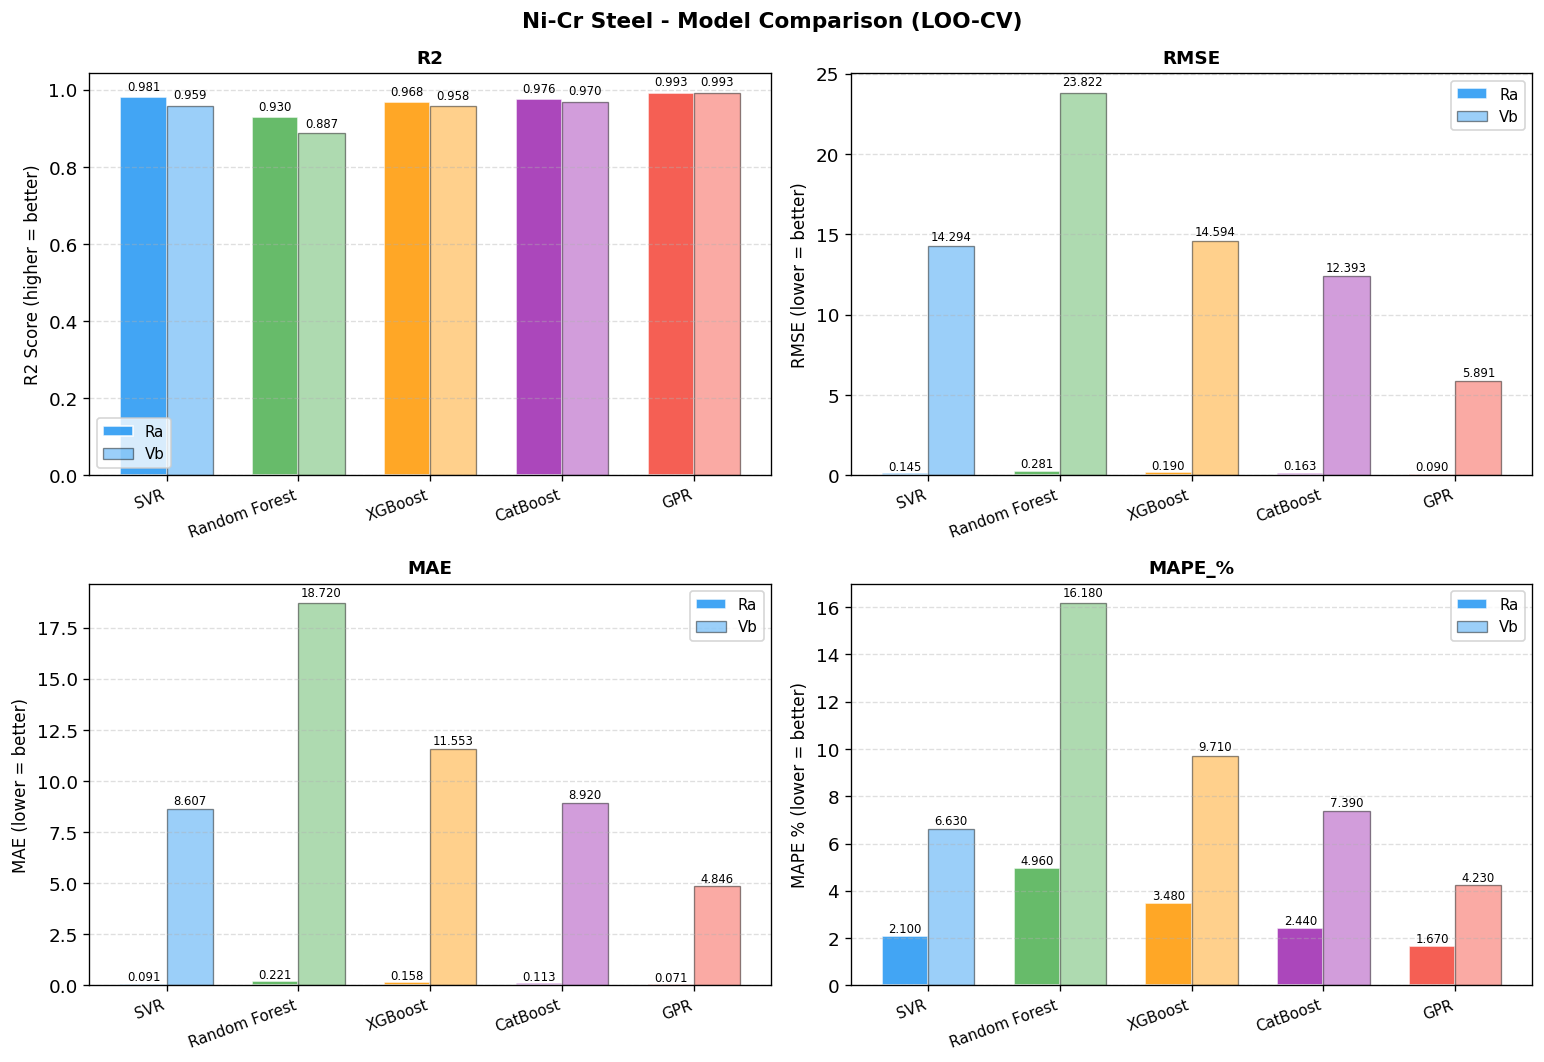

Saved: NiCr_ModelComparison.png


In [ ]:
# CELL 11 — MODEL COMPARISON BAR CHART
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Ni-Cr Steel - Model Comparison (LOO-CV)', fontsize=13, fontweight='bold')

colors_list = [COLORS[m] for m in MODEL_NAMES]
x = np.arange(len(MODEL_NAMES))
w = 0.35

metric_info = [
    ('R2',      'R2 Score (higher = better)'),
    ('RMSE',    'RMSE (lower = better)'),
    ('MAE',     'MAE (lower = better)'),
    ('MAPE_%',  'MAPE % (lower = better)'),
]

for idx, (metric, ylabel) in enumerate(metric_info):
    ax   = axes[idx // 2, idx % 2]
    vRa  = [results_Ra[m][metric] for m in MODEL_NAMES]
    vVb  = [results_Vb[m][metric] for m in MODEL_NAMES]
    bars1 = ax.bar(x - w/2, vRa, w, label='Ra', color=colors_list, alpha=0.85, edgecolor='white')
    bars2 = ax.bar(x + w/2, vVb, w, label='Vb', color=colors_list, alpha=0.45, edgecolor='black', lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_NAMES, rotation=20, ha='right', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(metric, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    for bar in list(bars1) + list(bars2):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h*1.01,
                f'{h:.3f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('NiCr_ModelComparison.png', dpi=300)
plt.show()
print('Saved: NiCr_ModelComparison.png')

Best model for Ra : GPR
Best model for Vb : GPR

Ra prediction range on training data : 2.719 – 6.434 um
Vb prediction range on training data : 34.9 – 297.9 um
Ra actual range : 2.700 – 6.450 um
Vb actual range : 35.0 – 300.0 um


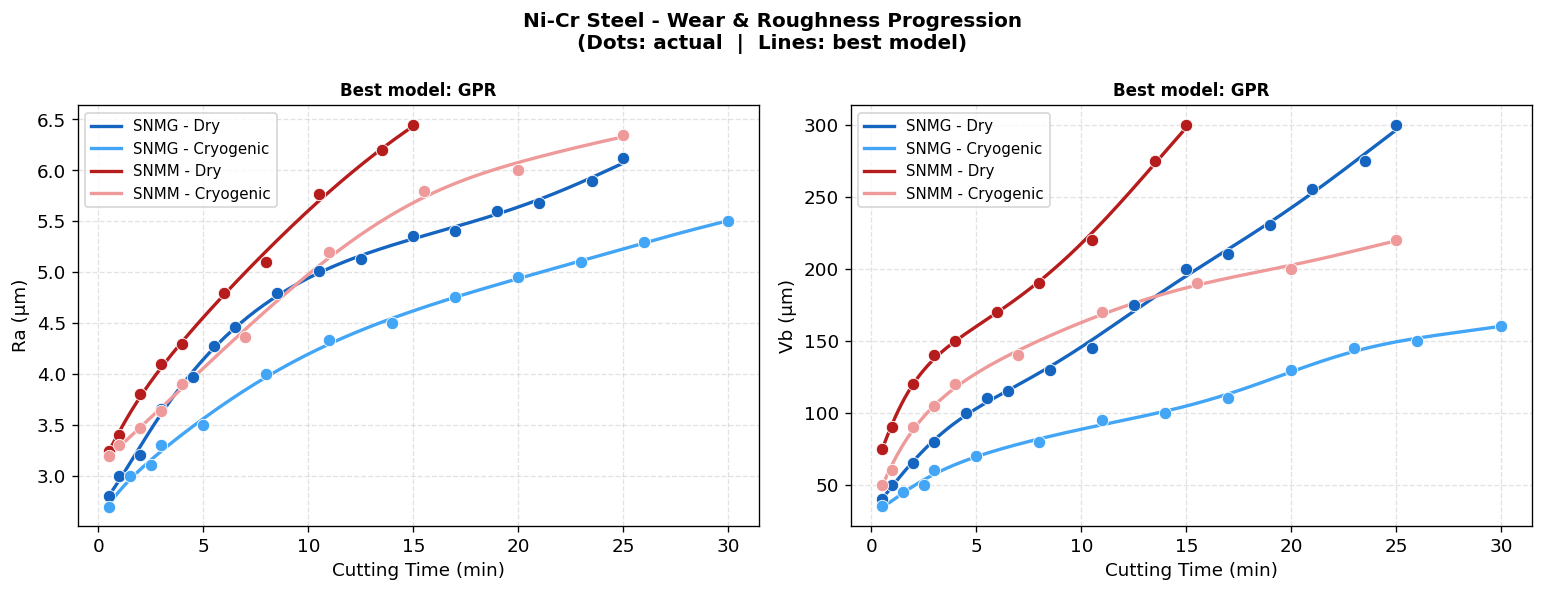

Saved: NiCr_ProgressionCurves_FIXED.png


In [ ]:
# ── CELL 12 FIX — Wear & Roughness Progression Curves ──────────────────────

from copy import deepcopy
import numpy as np
import matplotlib.pyplot as plt

best_Ra_name = max(results_Ra, key=lambda m: results_Ra[m]['R2'])
best_Vb_name = max(results_Vb, key=lambda m: results_Vb[m]['R2'])

print(f"Best model for Ra : {best_Ra_name}")
print(f"Best model for Vb : {best_Vb_name}")

# ── FIX: use deepcopy so each response always gets its own independent model ──
# This is critical when best_Ra_name == best_Vb_name (e.g., both are GPR)
models_Ra = get_models()
models_Vb = get_models()

ra_model = deepcopy(models_Ra[best_Ra_name])
vb_model = deepcopy(models_Vb[best_Vb_name])

ra_model.fit(X.values, y_Ra)
vb_model.fit(X.values, y_Vb)

# ── Verify the fit is correct before plotting ─────────────────────────────────
ra_train_pred = ra_model.predict(X.values)
vb_train_pred = vb_model.predict(X.values)

print(f"\nRa prediction range on training data : "
      f"{ra_train_pred.min():.3f} – {ra_train_pred.max():.3f} um")
print(f"Vb prediction range on training data : "
      f"{vb_train_pred.min():.1f} – {vb_train_pred.max():.1f} um")
print(f"Ra actual range : {y_Ra.min():.3f} – {y_Ra.max():.3f} um")
print(f"Vb actual range : {y_Vb.min():.1f} – {y_Vb.max():.1f} um")
# ─── If Ra predictions are in the 3–7 range, the fix worked. ─────────────────

groups = [
    ('SNMG 120408-26 TTS', 'Dry',       '#1565C0', 'SNMG - Dry'),
    ('SNMG 120408-26 TTS', 'Cryogenic', '#42A5F5', 'SNMG - Cryogenic'),
    ('SNMM 120408-26 TTS', 'Dry',       '#B71C1C', 'SNMM - Dry'),
    ('SNMM 120408-26 TTS', 'Cryogenic', '#EF9A9A', 'SNMM - Cryogenic'),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    'Ni-Cr Steel - Wear & Roughness Progression\n(Dots: actual  |  Lines: best model)',
    fontsize=12, fontweight='bold'
)

for ax_idx, (y_true, unit, model, mname) in enumerate([
    (y_Ra, 'Ra (µm)', ra_model, best_Ra_name),
    (y_Vb, 'Vb (µm)', vb_model, best_Vb_name),
]):
    ax = axes[ax_idx]

    for insert, env, color, label in groups:
        mask  = (df['Insert'] == insert) & (df['Environment'] == env)
        t_act = df.loc[mask, 'Time_min'].values
        y_act = y_true[mask]

        if len(t_act) == 0:
            continue  # skip missing group combinations

        t_line   = np.linspace(t_act.min(), t_act.max(), 200)
        ins_snmg = float('SNMG' in insert)
        env_dry  = float(env == 'Dry')

        # Guard: avoid log(0) if t_min is ever 0
        t_safe = np.clip(t_line, 1e-6, None)

        X_line = np.column_stack([
            np.full(200, ins_snmg),          # Insert_SNMG
            np.full(200, env_dry),            # Env_Dry
            t_line,                           # Time_min
            np.log(t_safe),                   # log_Time
            np.sqrt(t_line),                  # sqrt_Time
            t_line ** 2,                      # Time_sq
            ins_snmg * np.log(t_safe),        # Insert_x_logTime
            env_dry  * np.log(t_safe),        # Env_x_logTime
            np.full(200, ins_snmg * env_dry), # Insert_x_Env
        ])

        y_pred = model.predict(X_line)

        ax.scatter(t_act, y_act, color=color, s=55,
                   zorder=5, edgecolors='white', lw=0.5)
        ax.plot(t_line, y_pred, color=color, lw=2.0, label=label)

    ax.set_xlabel('Cutting Time (min)', fontsize=11)
    ax.set_ylabel(unit, fontsize=11)
    ax.set_title(f'Best model: {mname}', fontsize=10, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.35)

plt.tight_layout()
plt.savefig('NiCr_ProgressionCurves_FIXED.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: NiCr_ProgressionCurves_FIXED.png')

In [ ]:
# CELL 13 — EXPORT TO EXCEL
with pd.ExcelWriter('NiCr_ML_Results.xlsx', engine='openpyxl') as writer:

    for sheet, res in [('Ra Metrics', results_Ra), ('Vb Metrics', results_Vb)]:
        df_out = pd.DataFrame(res).T
        df_out.columns = ['R2', 'RMSE', 'MAE', 'MAPE (%)']
        df_out.index.name = 'Model'
        df_out.to_excel(writer, sheet_name=sheet)

    pred_df = pd.DataFrame({
        'Insert':      df['Insert'].values,
        'Environment': df['Environment'].values,
        'Time_min':    df['Time_min'].values,
        'Actual_Ra':   y_Ra,
        'Actual_Vb':   y_Vb,
    })
    for m in MODEL_NAMES:
        pred_df[f'Ra_Pred_{m}']     = preds_Ra[m]
        pred_df[f'Vb_Pred_{m}']     = preds_Vb[m]
        pred_df[f'Ra_Residual_{m}'] = y_Ra - preds_Ra[m]
        pred_df[f'Vb_Residual_{m}'] = y_Vb - preds_Vb[m]
    pred_df.to_excel(writer, sheet_name='All Predictions', index=False)

print('Saved: NiCr_ML_Results.xlsx')

Saved: NiCr_ML_Results.xlsx


In [ ]:
# CELL 14 — DOWNLOAD OUTPUT FILES TO YOUR COMPUTER
from google.colab import files

for fname in ['NiCr_ML_Results.xlsx', 'NiCr_PredVsActual.png',
              'NiCr_ModelComparison.png', 'NiCr_ProgressionCurves.png']:
    try:
        files.download(fname)
        print(f'Downloading: {fname}')
    except Exception as e:
        print(f'Could not download {fname}: {e}')

print('\nAll done! Check your Downloads folder.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: NiCr_ML_Results.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: NiCr_PredVsActual.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: NiCr_ModelComparison.png
Could not download NiCr_ProgressionCurves.png: Cannot find file: NiCr_ProgressionCurves.png

All done! Check your Downloads folder.


LOO-CV predictions collected.

── Bootstrap 95% CI — Ra ──────────────────────────────
Model                R² mean              95% CI R²   RMSE mean            95% CI RMSE
SVR                   0.9812 [0.9616, 0.9936]      0.1402 [0.0810, 0.2110]
Random Forest         0.9272 [0.8948, 0.9526]      0.2800 [0.2294, 0.3298]
XGBoost               0.9669 [0.9529, 0.9776]      0.1890 [0.1593, 0.2170]
CatBoost              0.9759 [0.9570, 0.9882]      0.1604 [0.1107, 0.2230]
GPR                   0.9926 [0.9894, 0.9954]      0.0893 [0.0691, 0.1107]

── Bootstrap 95% CI — Vb ──────────────────────────────
Model                R² mean              95% CI R²   RMSE mean            95% CI RMSE
SVR                   0.9598 [0.9321, 0.9843]     13.9119 [7.6244, 20.1255]
Random Forest         0.8834 [0.8316, 0.9252]     23.6494 [18.5867, 29.0318]
XGBoost               0.9561 [0.9348, 0.9729]     14.4977 [11.3240, 17.8542]
CatBoost              0.9690 [0.9556, 0.9811]     12.2644 [8.7850, 15.9125]
G

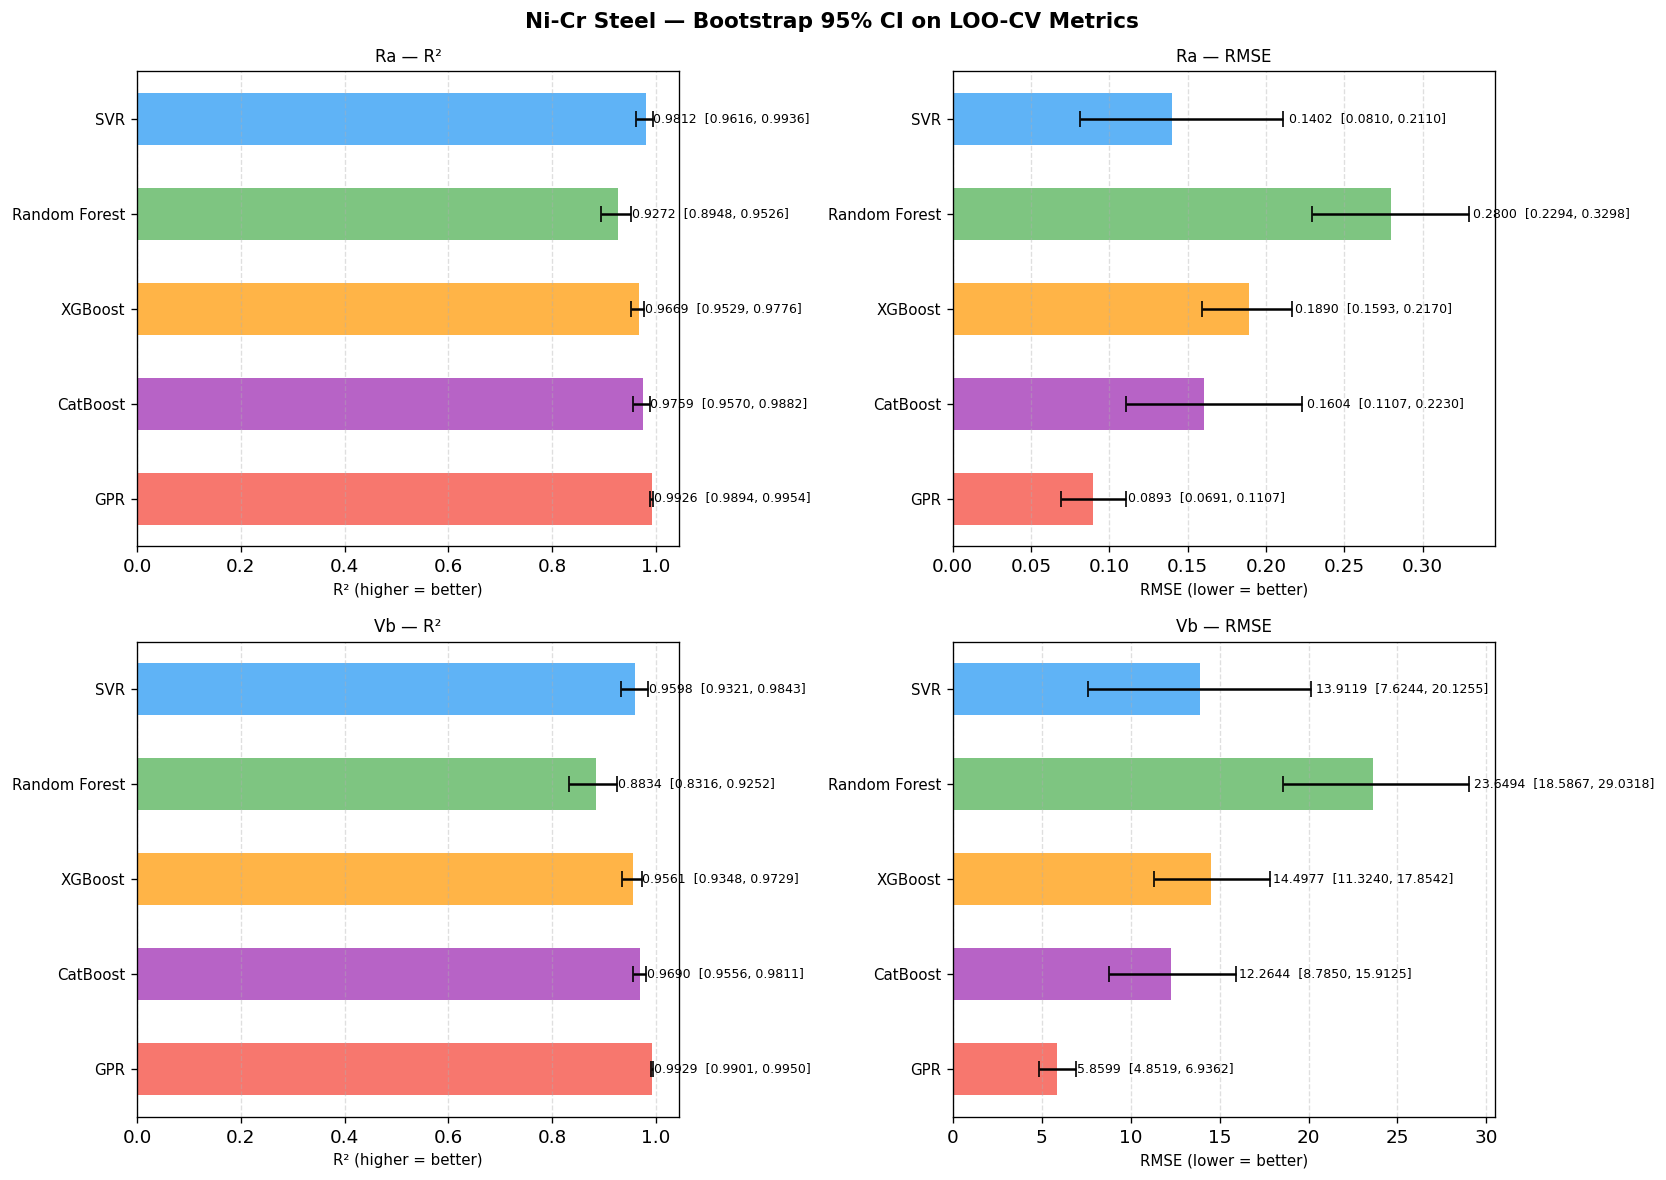

Saved: NiCr_Bootstrap_CI.png

Saved: NiCr_Bootstrap_CI_table.csv
Response         Model  R2_mean  R2_CI_lo  R2_CI_hi  RMSE_mean  RMSE_CI_lo  RMSE_CI_hi
      Ra           SVR   0.9812    0.9616    0.9936     0.1402      0.0810      0.2110
      Ra Random Forest   0.9272    0.8948    0.9526     0.2800      0.2294      0.3298
      Ra       XGBoost   0.9669    0.9529    0.9776     0.1890      0.1593      0.2170
      Ra      CatBoost   0.9759    0.9570    0.9882     0.1604      0.1107      0.2230
      Ra           GPR   0.9926    0.9894    0.9954     0.0893      0.0691      0.1107
      Vb           SVR   0.9598    0.9321    0.9843    13.9119      7.6244     20.1255
      Vb Random Forest   0.8834    0.8316    0.9252    23.6494     18.5867     29.0318
      Vb       XGBoost   0.9561    0.9348    0.9729    14.4977     11.3240     17.8542
      Vb      CatBoost   0.9690    0.9556    0.9811    12.2644      8.7850     15.9125
      Vb           GPR   0.9929    0.9901    0.9950     5.8599   

In [ ]:
# ── CELL 15— STATISTICAL MODEL COMPARISON ──────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import friedmanchisquare, wilcoxon
from itertools import combinations
from copy import deepcopy

np.random.seed(42)
N_BOOTSTRAP = 10_000
ALPHA       = 0.05

# ── Convert to numpy safely regardless of whether they are Series or ndarray ──
y_Ra_arr = np.array(y_Ra)   # safe for both pandas Series and numpy array
y_Vb_arr = np.array(y_Vb)

# ── STEP 0: Re-run LOO-CV and store per-sample predictions ───────────────────
from sklearn.model_selection import LeaveOneOut

loo         = LeaveOneOut()
model_names = list(get_models().keys())

loo_preds = {
    'Ra': {m: np.zeros(len(y_Ra_arr)) for m in model_names},
    'Vb': {m: np.zeros(len(y_Vb_arr)) for m in model_names},
}

for train_idx, test_idx in loo.split(X):
    X_tr = X.values[train_idx]
    X_te = X.values[test_idx]

    for response, y_all in [('Ra', y_Ra_arr), ('Vb', y_Vb_arr)]:   # ← FIX: no .values
        y_tr       = y_all[train_idx]
        models_loo = get_models()

        for mname, model in models_loo.items():
            model.fit(X_tr, y_tr)
            loo_preds[response][mname][test_idx] = model.predict(X_te)

print("LOO-CV predictions collected.")

# ── STEP 1: Per-sample absolute errors ───────────────────────────────────────
abs_errors = {}
for response, y_all in [('Ra', y_Ra_arr), ('Vb', y_Vb_arr)]:       # ← FIX: no .values
    abs_errors[response] = {
        m: np.abs(y_all - loo_preds[response][m]) for m in model_names
    }

# ── STEP 2: Bootstrap 95% CI on RMSE and R² ──────────────────────────────────
def bootstrap_metrics(y_true, y_pred, n_boot=N_BOOTSTRAP):
    n = len(y_true)
    rmse_boot, r2_boot = [], []
    for _ in range(n_boot):
        idx = np.random.choice(n, n, replace=True)
        yt, yp = y_true[idx], y_pred[idx]
        ss_res = np.sum((yt - yp) ** 2)
        ss_tot = np.sum((yt - yt.mean()) ** 2)
        rmse_boot.append(np.sqrt(ss_res / n))
        r2_boot.append(1 - ss_res / ss_tot if ss_tot > 0 else 0.0)
    return {
        'R2_mean':    np.mean(r2_boot),
        'R2_lo':      np.percentile(r2_boot,   2.5),
        'R2_hi':      np.percentile(r2_boot,  97.5),
        'RMSE_mean':  np.mean(rmse_boot),
        'RMSE_lo':    np.percentile(rmse_boot,  2.5),
        'RMSE_hi':    np.percentile(rmse_boot, 97.5),
    }

boot_results = {}
for response, y_all in [('Ra', y_Ra_arr), ('Vb', y_Vb_arr)]:       # ← FIX: no .values
    boot_results[response] = {
        m: bootstrap_metrics(y_all, loo_preds[response][m])
        for m in model_names
    }

# Print Bootstrap CI table
for response in ['Ra', 'Vb']:
    print(f"\n── Bootstrap 95% CI — {response} ──────────────────────────────")
    print(f"{'Model':<18} {'R² mean':>9} {'95% CI R²':>22}  "
          f"{'RMSE mean':>10} {'95% CI RMSE':>22}")
    for m in model_names:
        b = boot_results[response][m]
        print(f"{m:<18} {b['R2_mean']:>9.4f} "
              f"[{b['R2_lo']:.4f}, {b['R2_hi']:.4f}]  "
              f"{b['RMSE_mean']:>10.4f} "
              f"[{b['RMSE_lo']:.4f}, {b['RMSE_hi']:.4f}]")

# ── STEP 3: Friedman Test ─────────────────────────────────────────────────────
print("\n── Friedman Test ────────────────────────────────────────────────────")
for response in ['Ra', 'Vb']:
    arrays = [abs_errors[response][m] for m in model_names]
    stat, p = friedmanchisquare(*arrays)
    sig = "✓ SIGNIFICANT — pairwise tests valid" if p < ALPHA else "✗ NOT significant"
    print(f"  {response}: χ²={stat:.4f},  p={p:.6f}  →  {sig}")

# ── STEP 4: Pairwise Wilcoxon + Holm–Bonferroni correction ───────────────────
def holm_bonferroni(p_dict):
    pairs  = list(p_dict.keys())
    pvals  = np.array([p_dict[k] for k in pairs])
    n      = len(pvals)
    order  = np.argsort(pvals)
    corrected = np.zeros(n)
    for rank, idx in enumerate(order):
        corrected[idx] = min(pvals[idx] * (n - rank), 1.0)
    for i in range(1, n):
        corrected[order[i]] = max(corrected[order[i]], corrected[order[i-1]])
    return {pairs[i]: corrected[i] for i in range(n)}

pairwise_results = {}
for response in ['Ra', 'Vb']:
    raw_p = {}
    for m1, m2 in combinations(model_names, 2):
        e1, e2 = abs_errors[response][m1], abs_errors[response][m2]
        if np.all(e1 == e2):
            raw_p[(m1, m2)] = 1.0
        else:
            _, p = wilcoxon(e1, e2, alternative='two-sided', zero_method='wilcox')
            raw_p[(m1, m2)] = p
    pairwise_results[response] = holm_bonferroni(raw_p)

print("\n── Pairwise Wilcoxon — Holm–Bonferroni corrected ────────────────────")
for response in ['Ra', 'Vb']:
    print(f"\n  {response}:")
    print(f"  {'Pair':<42} {'p_corrected':>12}  {'Sig?':>6}")
    for (m1, m2), p_c in sorted(pairwise_results[response].items()):
        sig = "YES *" if p_c < ALPHA else "no"
        print(f"  {m1:<18} vs {m2:<18}  {p_c:>12.4f}  {sig:>6}")

# ── STEP 5: Forest Plot of Bootstrap CIs ─────────────────────────────────────
colors_model = {
    'SVR':           '#2196F3',
    'Random Forest': '#4CAF50',
    'XGBoost':       '#FF9800',
    'CatBoost':      '#9C27B0',
    'GPR':           '#F44336',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Ni-Cr Steel — Bootstrap 95% CI on LOO-CV Metrics',
             fontsize=13, fontweight='bold')

metric_configs = [
    ('R2_mean',   'R2_lo',   'R2_hi',   'R² (higher = better)'),
    ('RMSE_mean', 'RMSE_lo', 'RMSE_hi', 'RMSE (lower = better)'),
]

for row, (response, y_all) in enumerate([('Ra', y_Ra_arr), ('Vb', y_Vb_arr)]):  # ← FIX
    for col, (mk, lo_k, hi_k, xlabel) in enumerate(metric_configs):
        ax = axes[row][col]
        y_pos = np.arange(len(model_names))

        for i, m in enumerate(model_names):
            b  = boot_results[response][m]
            mn, lo, hi = b[mk], b[lo_k], b[hi_k]
            ax.barh(i, mn, color=colors_model[m], alpha=0.72, height=0.55)
            ax.errorbar(mn, i,
                        xerr=[[mn - lo], [hi - mn]],
                        fmt='none', color='black', capsize=5, lw=1.5)
            ax.text(hi + abs(hi - mn) * 0.05 + 1e-4, i,
                    f'{mn:.4f}  [{lo:.4f}, {hi:.4f}]',
                    va='center', fontsize=7.5)

        ax.set_yticks(y_pos)
        ax.set_yticklabels(model_names, fontsize=9)
        ax.set_xlabel(xlabel, fontsize=9)
        ax.set_title(f'{response} — {xlabel.split("(")[0].strip()}', fontsize=10)
        ax.grid(True, axis='x', linestyle='--', alpha=0.4)
        ax.invert_yaxis()

plt.tight_layout()
plt.savefig('NiCr_Bootstrap_CI.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: NiCr_Bootstrap_CI.png")

# ── STEP 6: Export CSV summary ────────────────────────────────────────────────
rows = []
for response in ['Ra', 'Vb']:
    for m in model_names:
        b = boot_results[response][m]
        rows.append({
            'Response':   response,
            'Model':      m,
            'R2_mean':    round(b['R2_mean'],   4),
            'R2_CI_lo':   round(b['R2_lo'],     4),
            'R2_CI_hi':   round(b['R2_hi'],     4),
            'RMSE_mean':  round(b['RMSE_mean'], 4),
            'RMSE_CI_lo': round(b['RMSE_lo'],   4),
            'RMSE_CI_hi': round(b['RMSE_hi'],   4),
        })

df_stats = pd.DataFrame(rows)
df_stats.to_csv('NiCr_Bootstrap_CI_table.csv', index=False)
print("\nSaved: NiCr_Bootstrap_CI_table.csv")
print(df_stats.to_string(index=False))

── Shapiro-Wilk Normality Test on GPR LOO-CV Residuals ──────────────
  Ra: W=0.9721,  p=0.2918  →  ✓ Normal (fail to reject H0)
  Vb: W=0.9692,  p=0.2246  →  ✓ Normal (fail to reject H0)


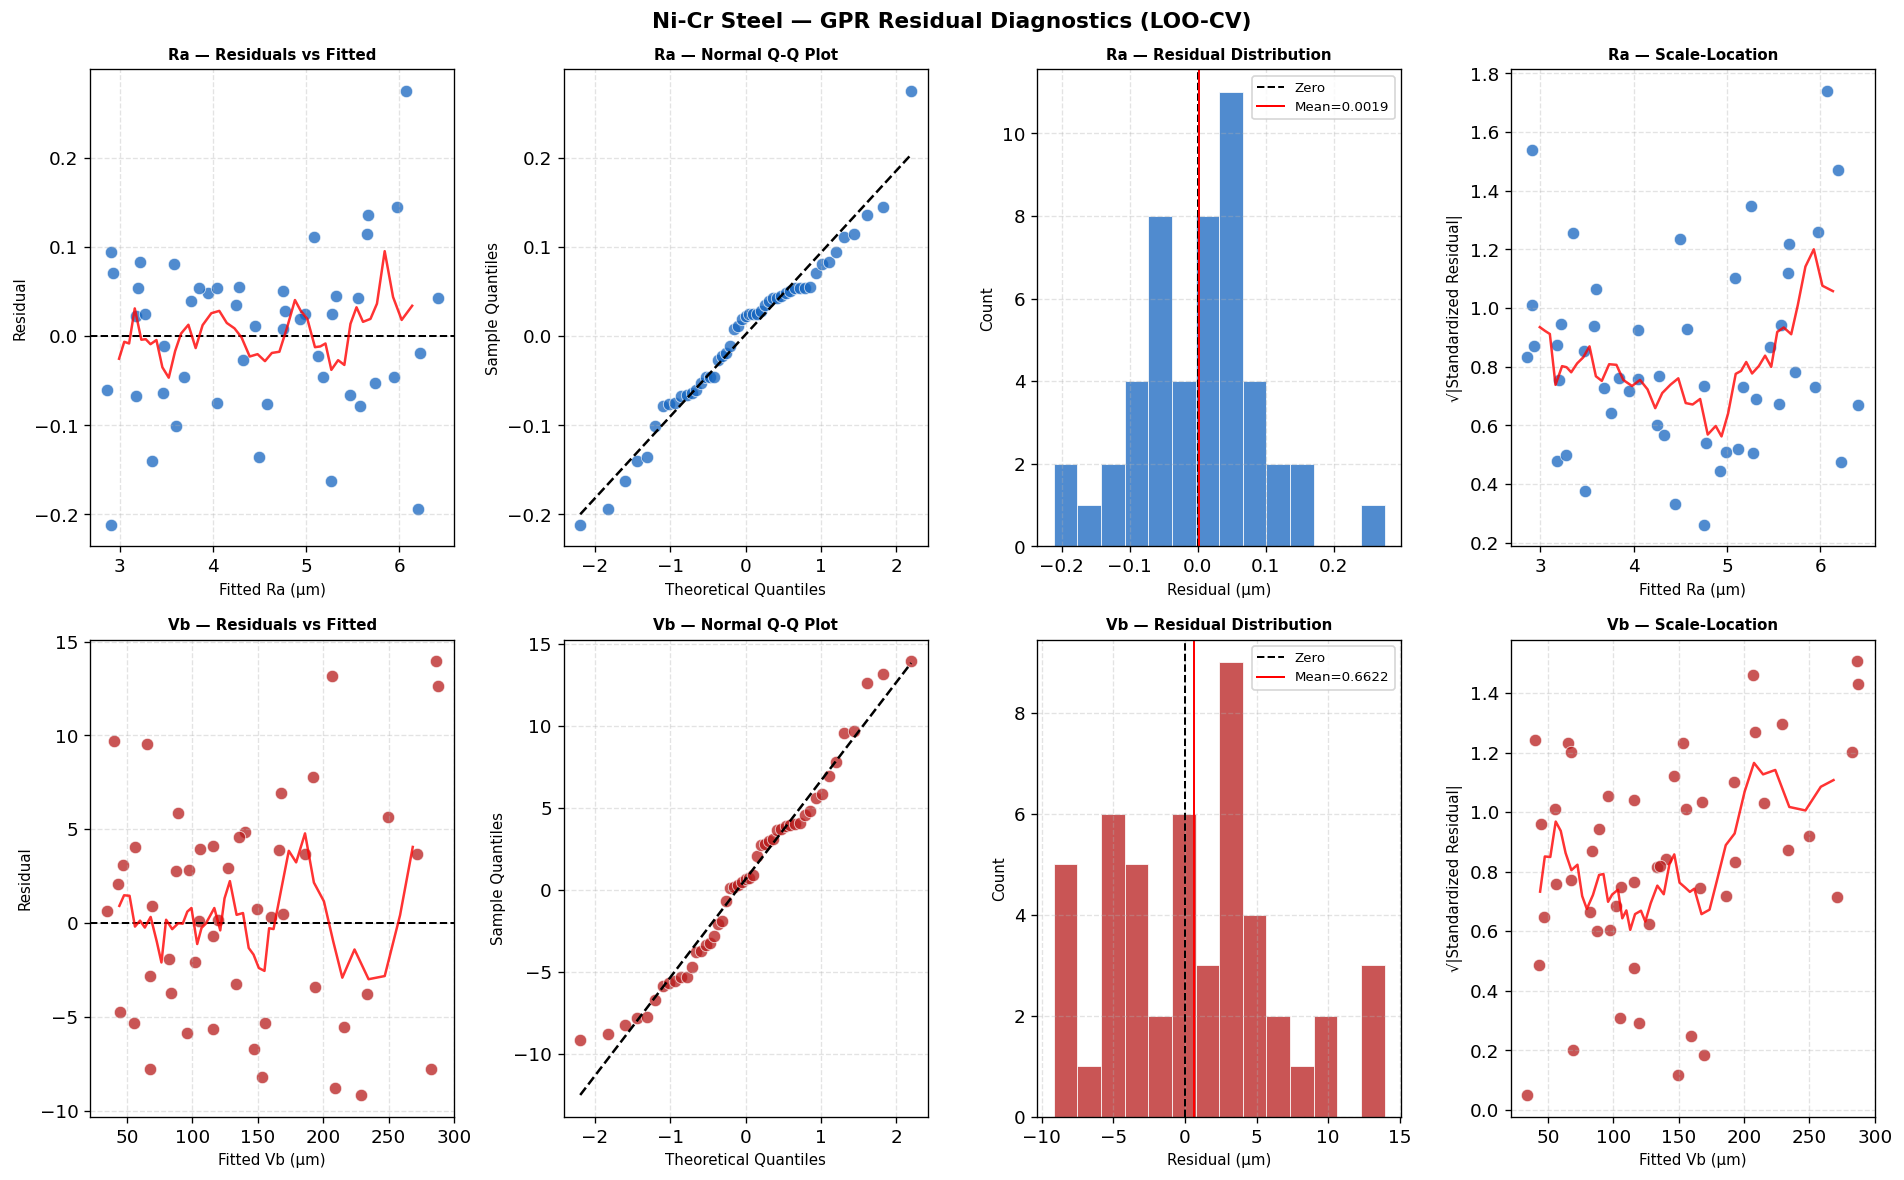

Saved: NiCr_GPR_Residuals.png

── GPR Residual Summary ──────────────────────────────────────────────

  Ra:
    Mean residual   : 0.001917  (ideal = 0)
    Std residual    : 0.0901
    Max |residual|  : 0.2749
    % within ±1σ    : 75.5%  (normal = 68.3%)
    % within ±2σ    : 93.9%  (normal = 95.4%)

  Vb:
    Mean residual   : 0.662207  (ideal = 0)
    Std residual    : 5.8536
    Max |residual|  : 13.9490
    % within ±1σ    : 71.4%  (normal = 68.3%)
    % within ±2σ    : 93.9%  (normal = 95.4%)


In [ ]:
# ── CELL 16 — GPR RESIDUAL ANALYSIS ─────────────────────────────────────────
# Validates GPR assumptions: normality, homoscedasticity, no systematic bias
# Required before trusting GPR prediction intervals
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import shapiro, probplot
from copy import deepcopy

# ── Get GPR LOO-CV residuals (already computed in Cell 13) ───────────────────
residuals = {
    'Ra': y_Ra_arr - loo_preds['Ra']['GPR'],
    'Vb': y_Vb_arr - loo_preds['Vb']['GPR'],
}
fitted = {
    'Ra': loo_preds['Ra']['GPR'],
    'Vb': loo_preds['Vb']['GPR'],
}

# ── Shapiro-Wilk normality test ───────────────────────────────────────────────
print("── Shapiro-Wilk Normality Test on GPR LOO-CV Residuals ──────────────")
for response in ['Ra', 'Vb']:
    stat, p = shapiro(residuals[response])
    interp = "✓ Normal (fail to reject H0)" if p > 0.05 else "✗ Non-normal (reject H0)"
    print(f"  {response}: W={stat:.4f},  p={p:.4f}  →  {interp}")

# ── Standardize residuals for plotting ───────────────────────────────────────
std_resid = {r: (residuals[r] - residuals[r].mean()) / residuals[r].std()
             for r in ['Ra', 'Vb']}

# ── Plot: 4 diagnostic panels per response ───────────────────────────────────
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Ni-Cr Steel — GPR Residual Diagnostics (LOO-CV)',
             fontsize=13, fontweight='bold')

colors = {'Ra': '#1565C0', 'Vb': '#B71C1C'}

for row_idx, response in enumerate(['Ra', 'Vb']):
    res   = residuals[response]
    std_r = std_resid[response]
    fit   = fitted[response]
    unit  = 'µm' if response == 'Ra' else 'µm'

    # ── Panel 1: Residuals vs Fitted ─────────────────────────────────────────
    ax1 = fig.add_subplot(2, 4, row_idx * 4 + 1)
    ax1.scatter(fit, res, color=colors[response], alpha=0.75,
                edgecolors='white', lw=0.5, s=55)
    ax1.axhline(0, color='black', lw=1.2, linestyle='--')
    # Loess-style moving mean to check for trend
    sort_idx = np.argsort(fit)
    window   = max(5, len(fit) // 8)
    smooth_x = np.convolve(fit[sort_idx],   np.ones(window)/window, mode='valid')
    smooth_y = np.convolve(res[sort_idx],   np.ones(window)/window, mode='valid')
    ax1.plot(smooth_x, smooth_y, color='red', lw=1.5, linestyle='-', alpha=0.8)
    ax1.set_xlabel(f'Fitted {response} ({unit})', fontsize=9)
    ax1.set_ylabel('Residual', fontsize=9)
    ax1.set_title(f'{response} — Residuals vs Fitted', fontsize=9, fontweight='bold')
    ax1.grid(True, linestyle='--', alpha=0.35)

    # ── Panel 2: Q-Q Plot ─────────────────────────────────────────────────────
    ax2 = fig.add_subplot(2, 4, row_idx * 4 + 2)
    (osm, osr), (slope, intercept, r) = probplot(res, dist='norm')
    ax2.scatter(osm, osr, color=colors[response], alpha=0.75,
                edgecolors='white', lw=0.5, s=55)
    qq_line = np.array([osm[0], osm[-1]])
    ax2.plot(qq_line, slope * qq_line + intercept,
             color='black', lw=1.5, linestyle='--')
    ax2.set_xlabel('Theoretical Quantiles', fontsize=9)
    ax2.set_ylabel('Sample Quantiles', fontsize=9)
    ax2.set_title(f'{response} — Normal Q-Q Plot', fontsize=9, fontweight='bold')
    ax2.grid(True, linestyle='--', alpha=0.35)

    # ── Panel 3: Histogram of residuals ──────────────────────────────────────
    ax3 = fig.add_subplot(2, 4, row_idx * 4 + 3)
    ax3.hist(res, bins=14, color=colors[response], alpha=0.75,
             edgecolor='white', linewidth=0.6)
    ax3.axvline(0,            color='black', lw=1.2, linestyle='--', label='Zero')
    ax3.axvline(res.mean(),   color='red',   lw=1.2, linestyle='-',
                label=f'Mean={res.mean():.4f}')
    ax3.set_xlabel(f'Residual ({unit})', fontsize=9)
    ax3.set_ylabel('Count', fontsize=9)
    ax3.set_title(f'{response} — Residual Distribution', fontsize=9, fontweight='bold')
    ax3.legend(fontsize=8)
    ax3.grid(True, linestyle='--', alpha=0.35)

    # ── Panel 4: Scale-Location (sqrt|std resid| vs fitted) ──────────────────
    ax4 = fig.add_subplot(2, 4, row_idx * 4 + 4)
    ax4.scatter(fit, np.sqrt(np.abs(std_r)), color=colors[response],
                alpha=0.75, edgecolors='white', lw=0.5, s=55)
    smooth_y2 = np.convolve(np.sqrt(np.abs(std_r))[sort_idx],
                            np.ones(window)/window, mode='valid')
    ax4.plot(smooth_x, smooth_y2, color='red', lw=1.5, alpha=0.8)
    ax4.set_xlabel(f'Fitted {response} ({unit})', fontsize=9)
    ax4.set_ylabel('√|Standardized Residual|', fontsize=9)
    ax4.set_title(f'{response} — Scale-Location', fontsize=9, fontweight='bold')
    ax4.grid(True, linestyle='--', alpha=0.35)

plt.tight_layout()
plt.savefig('NiCr_GPR_Residuals.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: NiCr_GPR_Residuals.png")

# ── Summary statistics ────────────────────────────────────────────────────────
print("\n── GPR Residual Summary ──────────────────────────────────────────────")
for response in ['Ra', 'Vb']:
    res = residuals[response]
    print(f"\n  {response}:")
    print(f"    Mean residual   : {res.mean():.6f}  (ideal = 0)")
    print(f"    Std residual    : {res.std():.4f}")
    print(f"    Max |residual|  : {np.abs(res).max():.4f}")
    print(f"    % within ±1σ    : {(np.abs(res) <= res.std()).mean()*100:.1f}%  (normal = 68.3%)")
    print(f"    % within ±2σ    : {(np.abs(res) <= 2*res.std()).mean()*100:.1f}%  (normal = 95.4%)")

Ra prediction range : 2.719 – 6.434 µm  (actual: 2.700 – 6.450)
Vb prediction range : 34.9  – 297.9  µm  (actual: 35.0  – 300.0)


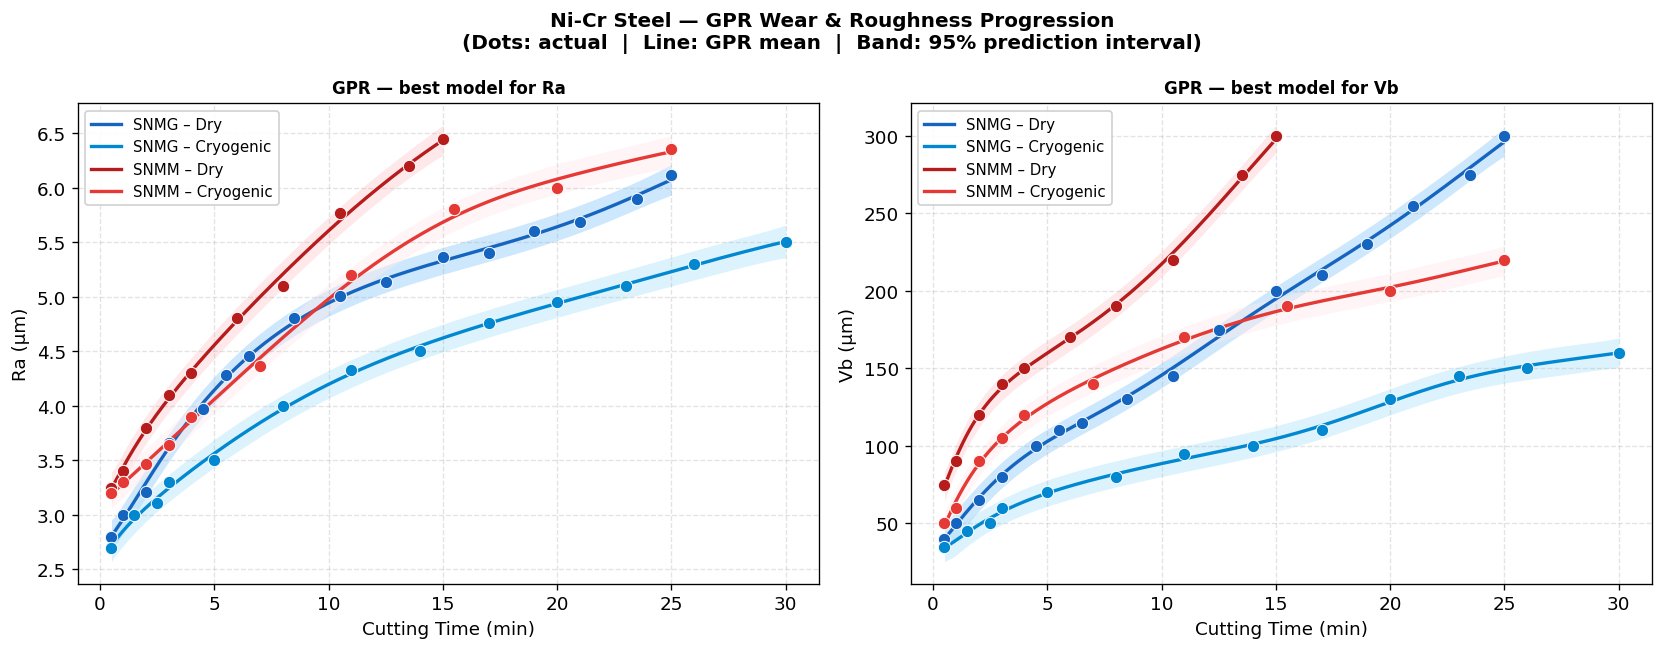

Saved: NiCr_GPR_ProgressionWithCI.png


In [ ]:
# ── CELL 17 — GPR PROGRESSION CURVES WITH UNCERTAINTY BANDS ─────────────────
# Replaces Cell 12. Adds ±1.96σ posterior std bands (GPR unique capability).
# This is the key visualization that differentiates GPR from all other models.
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy

# ── Refit GPR on full data (two independent instances) ───────────────────────
from sklearn.gaussian_process import GaussianProcessRegressor

models_Ra_full = get_models()
models_Vb_full = get_models()

ra_model_full = deepcopy(models_Ra_full['GPR'])
vb_model_full = deepcopy(models_Vb_full['GPR'])

ra_model_full.fit(X.values, y_Ra_arr)
vb_model_full.fit(X.values, y_Vb_arr)

# Verify ranges before plotting
ra_check, ra_std_check = ra_model_full.predict(X.values, return_std=True)
vb_check, vb_std_check = vb_model_full.predict(X.values, return_std=True)
print(f"Ra prediction range : {ra_check.min():.3f} – {ra_check.max():.3f} µm  (actual: {y_Ra_arr.min():.3f} – {y_Ra_arr.max():.3f})")
print(f"Vb prediction range : {vb_check.min():.1f}  – {vb_check.max():.1f}  µm  (actual: {y_Vb_arr.min():.1f}  – {y_Vb_arr.max():.1f})")

# ── Group definitions ─────────────────────────────────────────────────────────
groups = [
    ('SNMG 120408-26 TTS', 'Dry',       '#1565C0', '#90CAF9', 'SNMG – Dry'),
    ('SNMG 120408-26 TTS', 'Cryogenic', '#0288D1', '#B3E5FC', 'SNMG – Cryogenic'),
    ('SNMM 120408-26 TTS', 'Dry',       '#B71C1C', '#FFCDD2', 'SNMM – Dry'),
    ('SNMM 120408-26 TTS', 'Cryogenic', '#E53935', '#FFEBEE', 'SNMM – Cryogenic'),
]
# (insert, env, line_color, band_color, label)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle(
    'Ni-Cr Steel — GPR Wear & Roughness Progression\n'
    '(Dots: actual  |  Line: GPR mean  |  Band: 95% prediction interval)',
    fontsize=12, fontweight='bold'
)

response_config = [
    (y_Ra_arr, 'Ra (µm)', ra_model_full, 'GPR — best model for Ra'),
    (y_Vb_arr, 'Vb (µm)', vb_model_full, 'GPR — best model for Vb'),
]

for ax_idx, (y_true, ylabel, model, subtitle) in enumerate(response_config):
    ax = axes[ax_idx]

    for insert, env, line_col, band_col, label in groups:
        mask  = (df['Insert'] == insert) & (df['Environment'] == env)
        t_act = df.loc[mask, 'Time_min'].values
        y_act = y_true[mask]

        if len(t_act) == 0:
            continue

        # Dense time grid for smooth curves
        t_line   = np.linspace(t_act.min(), t_act.max(), 300)
        t_safe   = np.clip(t_line, 1e-6, None)
        ins_snmg = float('SNMG' in insert)
        env_dry  = float(env == 'Dry')

        X_line = np.column_stack([
            np.full(300, ins_snmg),
            np.full(300, env_dry),
            t_line,
            np.log(t_safe),
            np.sqrt(t_line),
            t_line ** 2,
            ins_snmg * np.log(t_safe),
            env_dry  * np.log(t_safe),
            np.full(300, ins_snmg * env_dry),
        ])

        # GPR mean + posterior std
        y_mean, y_std = model.predict(X_line, return_std=True)
        y_lo = y_mean - 1.96 * y_std
        y_hi = y_mean + 1.96 * y_std

        # Plot: band first (behind), then mean line, then actual dots
        ax.fill_between(t_line, y_lo, y_hi,
                        color=band_col, alpha=0.45, linewidth=0)
        ax.plot(t_line, y_mean,
                color=line_col, lw=2.0, label=label)
        ax.scatter(t_act, y_act,
                   color=line_col, s=55, zorder=5,
                   edgecolors='white', linewidths=0.6)

    ax.set_xlabel('Cutting Time (min)', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(subtitle, fontsize=10, fontweight='bold')
    ax.legend(fontsize=9, framealpha=0.9)
    ax.grid(True, linestyle='--', alpha=0.35)

plt.tight_layout()
plt.savefig('NiCr_GPR_ProgressionWithCI.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: NiCr_GPR_ProgressionWithCI.png")

Computing SHAP for Ra... (this takes 1–3 min)
  Done. SHAP matrix shape: (49, 9)
Computing SHAP for Vb... (this takes 1–3 min)
  Done. SHAP matrix shape: (49, 9)


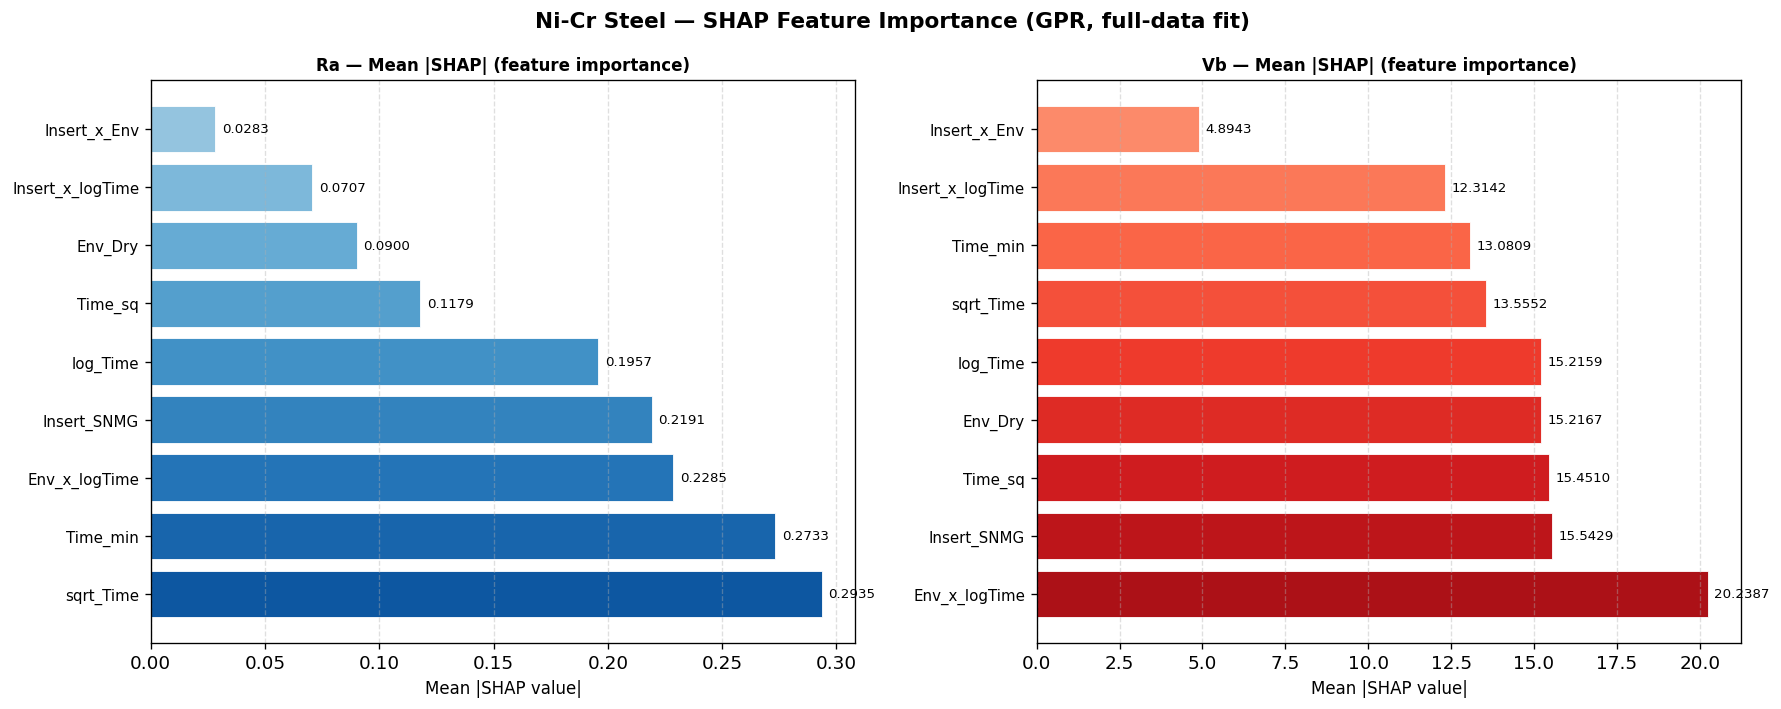

Saved: NiCr_SHAP_Importance.png

── SHAP Mean |Value| Ranking ────────────────────────────────────────
Rank   Feature                        Ra         Vb
--------------------------------------------------
1      sqrt_Time                  0.2935    13.5552
2      Time_min                   0.2733    13.0809
3      Env_x_logTime              0.2285    20.2387
4      Insert_SNMG                0.2191    15.5429
5      log_Time                   0.1957    15.2159
6      Time_sq                    0.1179    15.4510
7      Env_Dry                    0.0900    15.2167
8      Insert_x_logTime           0.0707    12.3142
9      Insert_x_Env               0.0283     4.8943

Saved: NiCr_SHAP_Ra.npy, NiCr_SHAP_Vb.npy


In [ ]:
# ── CELL 18 — SHAP FEATURE IMPORTANCE (GPR) ─────────────────────────────────
# KernelExplainer works with any sklearn model including GPR.
# Runtime: ~2–5 minutes for n=49. Be patient.
# ─────────────────────────────────────────────────────────────────────────────

import shap
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from copy import deepcopy

shap.initjs()

# ── Feature names (must match X column order) ─────────────────────────────────
feature_names = list(X.columns)   # preserves your exact column order

X_arr = X.values   # shape (49, 9)

# ── Use a small background summary to speed up KernelExplainer ───────────────
# shap.kmeans summarises the background distribution into k centroids
background = shap.kmeans(X_arr, 10)   # 10 representative background samples

shap_results = {}

for response, model, y_arr in [
    ('Ra', ra_model_full, y_Ra_arr),
    ('Vb', vb_model_full, y_Vb_arr),
]:
    print(f"Computing SHAP for {response}... (this takes 1–3 min)")
    explainer   = shap.KernelExplainer(model.predict, background)
    shap_values = explainer.shap_values(X_arr, nsamples=200, silent=True)
    # shap_values shape: (49, 9)
    shap_results[response] = shap_values
    print(f"  Done. SHAP matrix shape: {shap_values.shape}")

# ── Plot 1: Beeswarm (summary) plot for both responses ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Ni-Cr Steel — SHAP Feature Importance (GPR, full-data fit)',
             fontsize=13, fontweight='bold')

for ax_idx, (response, color_map) in enumerate([('Ra', 'Blues'), ('Vb', 'Reds')]):
    sv   = shap_results[response]          # (49, 9)
    mean_abs = np.abs(sv).mean(axis=0)     # mean |SHAP| per feature
    order = np.argsort(mean_abs)[::-1]     # highest to lowest

    ax = axes[ax_idx]
    colors_bar = plt.cm.get_cmap(color_map)(
        np.linspace(0.4, 0.85, len(feature_names))
    )
    bars = ax.barh(
        range(len(feature_names)),
        mean_abs[order],
        color=colors_bar[::-1],
        edgecolor='white', linewidth=0.5
    )
    ax.set_yticks(range(len(feature_names)))
    ax.set_yticklabels([feature_names[i] for i in order], fontsize=9)
    ax.set_xlabel('Mean |SHAP value|', fontsize=10)
    ax.set_title(f'{response} — Mean |SHAP| (feature importance)', fontsize=10,
                 fontweight='bold')
    ax.grid(True, axis='x', linestyle='--', alpha=0.4)

    # Annotate bars with values
    for bar, val in zip(bars, mean_abs[order]):
        ax.text(val + mean_abs.max() * 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('NiCr_SHAP_Importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: NiCr_SHAP_Importance.png")

# ── Plot 2: Side-by-side ranked table ─────────────────────────────────────────
print("\n── SHAP Mean |Value| Ranking ────────────────────────────────────────")
print(f"{'Rank':<6} {'Feature':<22} {'Ra':>10} {'Vb':>10}")
print("-" * 50)

ra_importance = pd.Series(
    np.abs(shap_results['Ra']).mean(axis=0), index=feature_names
).sort_values(ascending=False)

vb_importance = pd.Series(
    np.abs(shap_results['Vb']).mean(axis=0), index=feature_names
).sort_values(ascending=False)

all_features = feature_names
for rank, feat in enumerate(ra_importance.index, 1):
    print(f"{rank:<6} {feat:<22} {ra_importance[feat]:>10.4f} "
          f"{vb_importance.get(feat, 0):>10.4f}")

# ── Save SHAP values for later use ───────────────────────────────────────────
np.save('NiCr_SHAP_Ra.npy', shap_results['Ra'])
np.save('NiCr_SHAP_Vb.npy', shap_results['Vb'])
print("\nSaved: NiCr_SHAP_Ra.npy, NiCr_SHAP_Vb.npy")

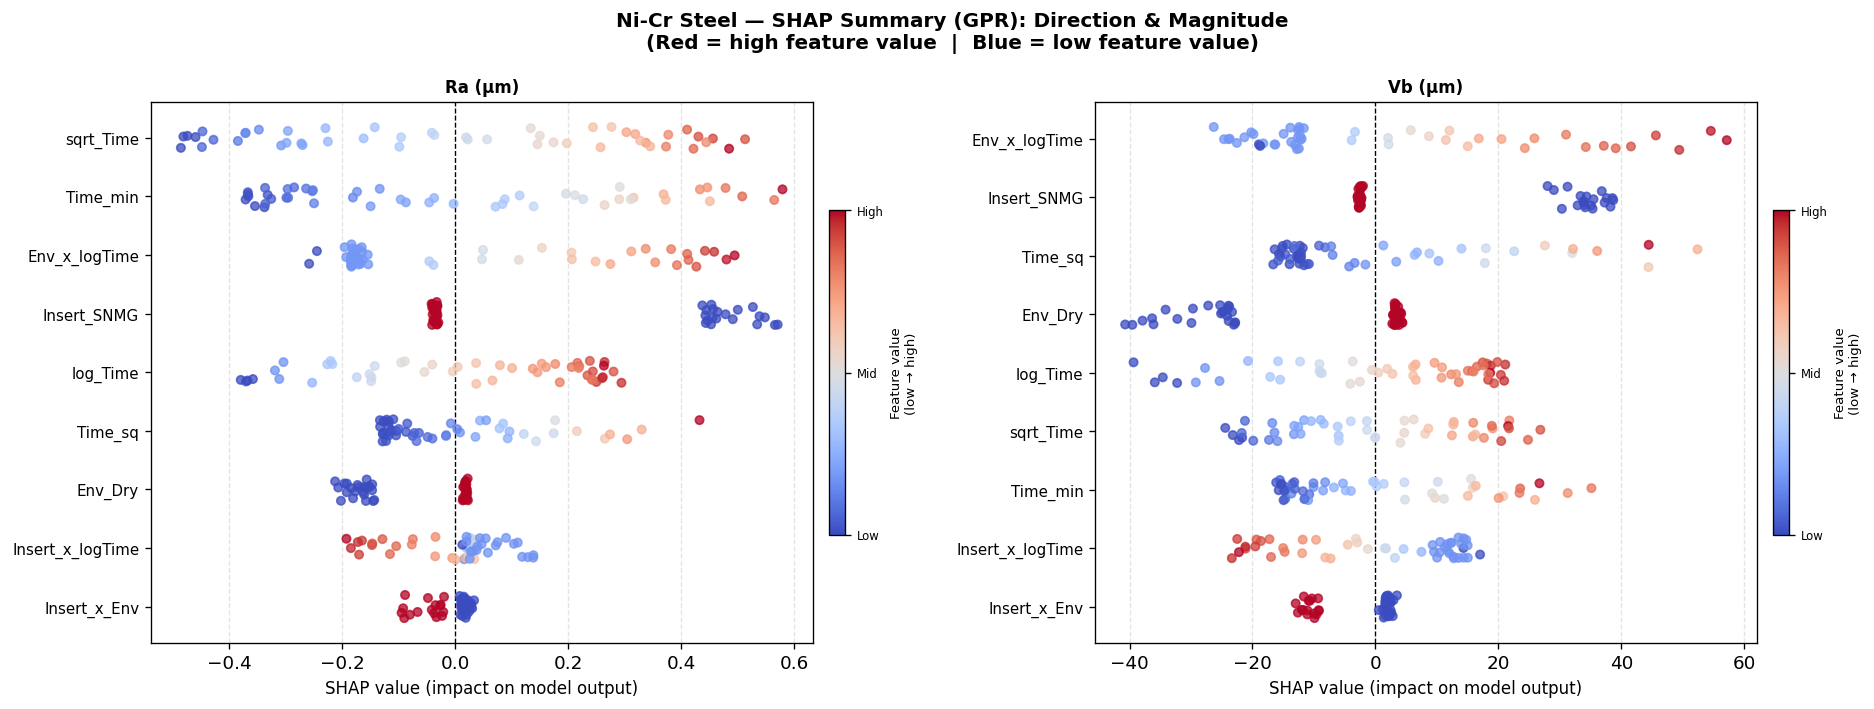

Saved: NiCr_SHAP_Direction.png


In [ ]:
# ── CELL 19 — SHAP Direction (Dot) Plot ─────────────────────────────────────
# Shows both importance magnitude AND whether each feature pushes prediction
# up (positive SHAP) or down (negative SHAP) for individual samples.
# ─────────────────────────────────────────────────────────────────────────────

import shap
import numpy as np
import matplotlib.pyplot as plt

feature_names = list(X.columns)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'Ni-Cr Steel — SHAP Summary (GPR): Direction & Magnitude\n'
    '(Red = high feature value  |  Blue = low feature value)',
    fontsize=12, fontweight='bold'
)

for ax_idx, (response, sv, color) in enumerate([
    ('Ra (µm)', shap_results['Ra'], plt.cm.coolwarm),
    ('Vb (µm)', shap_results['Vb'], plt.cm.coolwarm),
]):
    ax = axes[ax_idx]

    # Order features by mean |SHAP| descending (same as bar chart)
    mean_abs  = np.abs(sv).mean(axis=0)
    order     = np.argsort(mean_abs)          # ascending for horizontal plot
    sv_ord    = sv[:, order]
    X_ord     = X.values[:, order]
    feat_ord  = [feature_names[i] for i in order]
    n_feat    = len(feat_ord)

    for i in range(n_feat):
        shap_col = sv_ord[:, i]
        feat_col = X_ord[:, i]

        # Normalize feature values to [0,1] for color mapping
        feat_norm = (feat_col - feat_col.min()) / (feat_col.max() - feat_col.min() + 1e-9)
        colors    = color(feat_norm)

        # Jitter y-position to avoid overplotting
        y_jitter = np.random.uniform(-0.2, 0.2, len(shap_col))
        ax.scatter(shap_col, i + y_jitter,
                   c=colors, s=25, alpha=0.75, zorder=3)

    ax.axvline(0, color='black', lw=0.8, linestyle='--')
    ax.set_yticks(range(n_feat))
    ax.set_yticklabels(feat_ord, fontsize=9)
    ax.set_xlabel('SHAP value (impact on model output)', fontsize=10)
    ax.set_title(f'{response}', fontsize=10, fontweight='bold')
    ax.grid(True, axis='x', linestyle='--', alpha=0.35)

    # Colorbar
    sm = plt.cm.ScalarMappable(cmap=color,
                               norm=plt.Normalize(vmin=0, vmax=1))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
    cbar.set_label('Feature value\n(low → high)', fontsize=8)
    cbar.set_ticks([0, 0.5, 1])
    cbar.set_ticklabels(['Low', 'Mid', 'High'], fontsize=7)

plt.tight_layout()
plt.savefig('NiCr_SHAP_Direction.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: NiCr_SHAP_Direction.png")

Detected MAPE key: 'MAPE_%'
X shape: (49, 9) | y_Ra shape: (49,) | y_Vb shape: (49,)
  MLR (Linear)           Ra  R2=0.9826  RMSE=0.1401  MAPE=2.78%
  MLR (Linear)           Vb  R2=0.9435  RMSE=16.8614  MAPE=13.42%
  Poly Reg (deg2)        Ra  R2=0.2481  RMSE=0.9196  MAPE=9.75%
  Poly Reg (deg2)        Vb  R2=-0.2311  RMSE=78.6826  MAPE=58.44%

── Complete Model Comparison: Classical vs ML ──
          Model      Type Response      R2    RMSE  MAPE_%
            GPR        ML       Ra  0.9928  0.0902    1.67
   MLR (Linear) Classical       Ra  0.9826  0.1401    2.78
            SVR        ML       Ra  0.9813  0.1449    2.10
       CatBoost        ML       Ra  0.9763  0.1632    2.44
        XGBoost        ML       Ra  0.9680  0.1898    3.48
  Random Forest        ML       Ra  0.9298  0.2810    4.96
Poly Reg (deg2) Classical       Ra  0.2481  0.9196    9.75
            GPR        ML       Vb  0.9931  5.8909    4.23
       CatBoost        ML       Vb  0.9695 12.3932    7.39
            SV

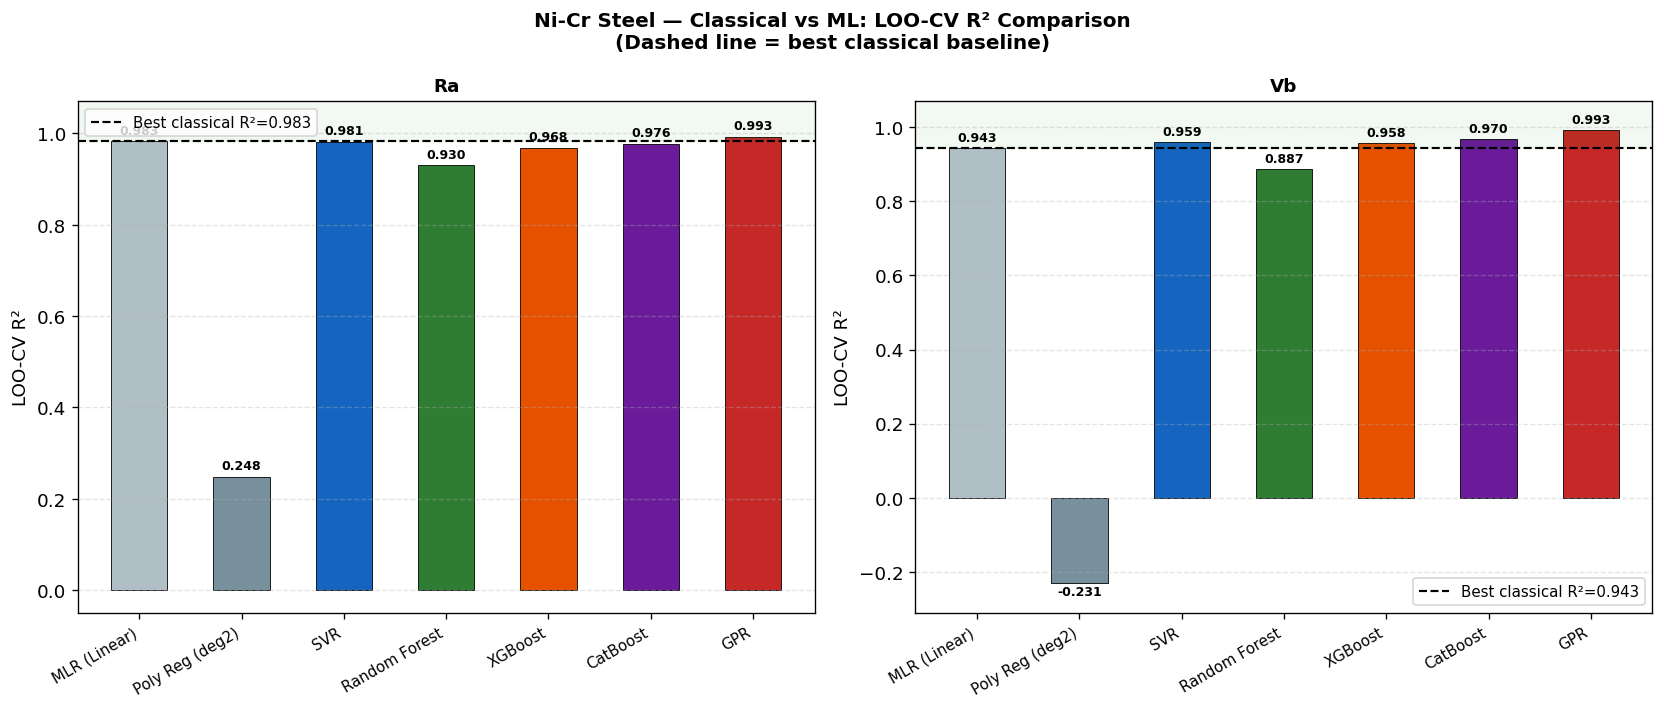

Saved: NiCr_Classical_vs_ML_R2.png


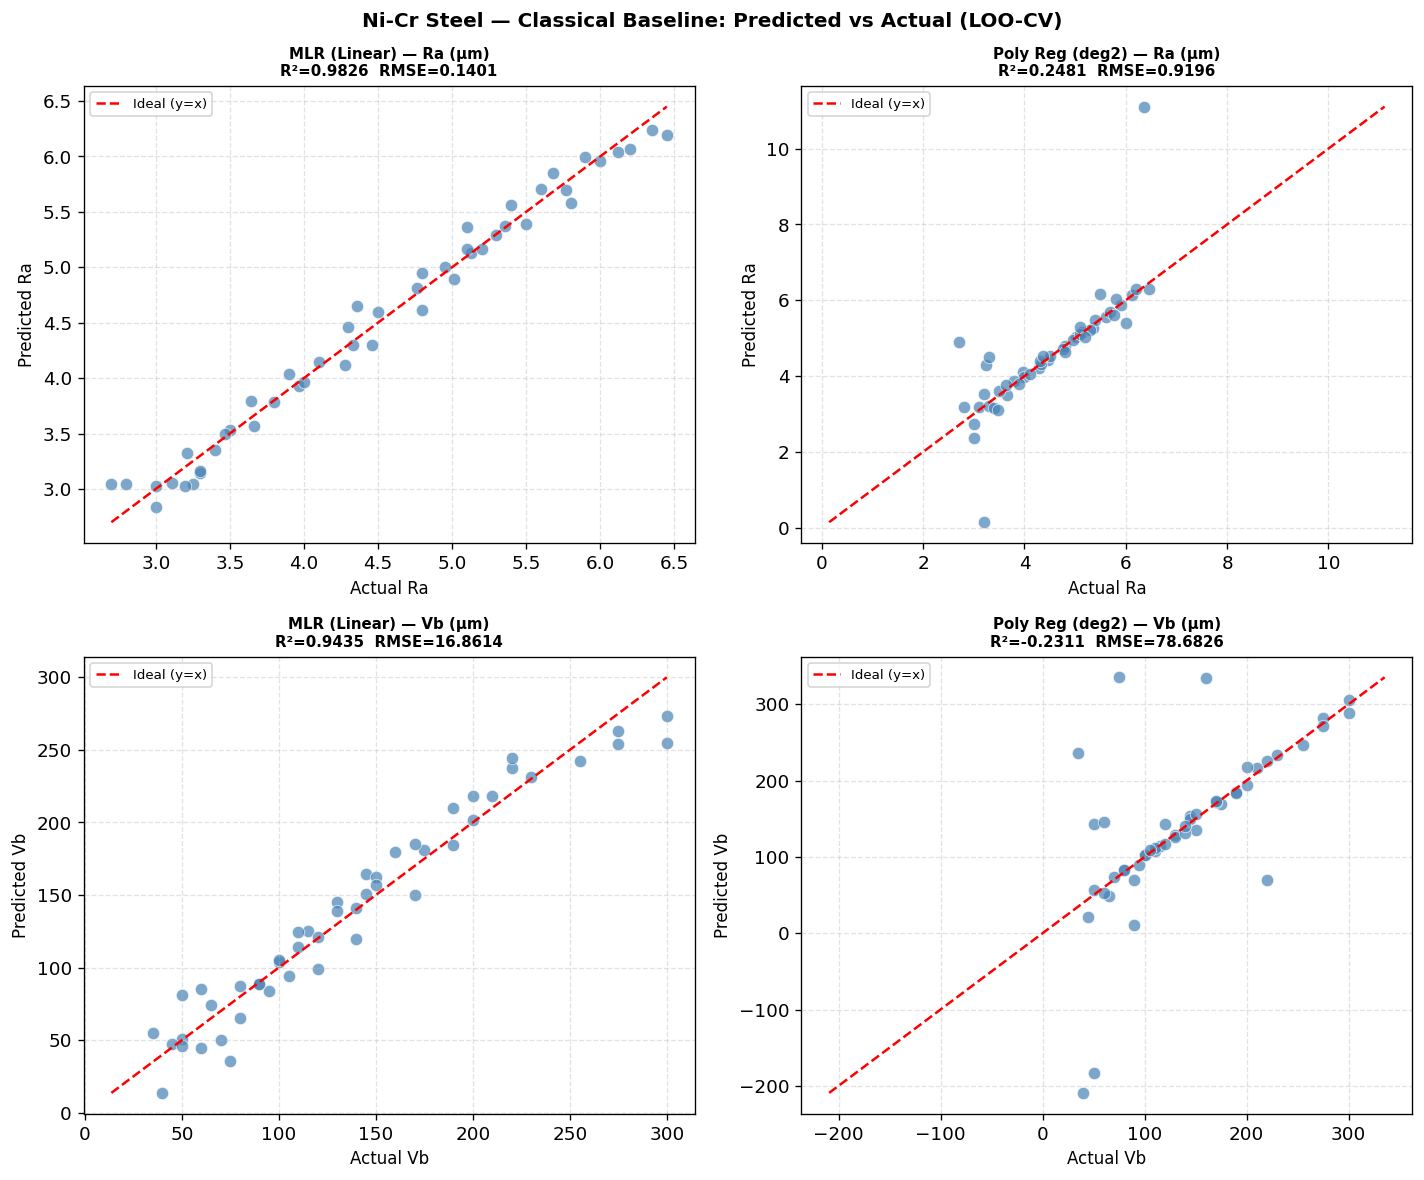

Saved: NiCr_Classical_PredVsActual.png

── P6 Complete. Modeling section for Ni-Cr is now fully publication-ready. ──


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 20 — CLASSICAL REGRESSION BASELINE (OLS + Polynomial)
# Purpose  : Justify why ML is needed by showing the gap vs classical stats
# Approach : Multiple Linear Regression + Polynomial Regression (degree 2)
#            using identical LOO-CV and same 9-feature matrix as ML models
# All errors fixed: numpy array handling + MAPE key auto-detection
# ═══════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 0: Auto-detect the MAPE key name used in your earlier results dict
# ─────────────────────────────────────────────────────────────────────────────
_first_model = list(results_Ra.keys())[0]
_possible_mape_keys = ['MAPE', 'MAPE_%', 'mape', 'mape_%']
_mape_key = None
for _k in _possible_mape_keys:
    if _k in results_Ra[_first_model]:
        _mape_key = _k
        break

if _mape_key is None:
    print(f"WARNING: Could not find MAPE key. Available keys: {list(results_Ra[_first_model].keys())}")
    print("Update _mape_key manually below.")
    _mape_key = list(results_Ra[_first_model].keys())[-1]  # fallback: last key
else:
    print(f"Detected MAPE key: '{_mape_key}'")

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1: Convert targets to plain numpy arrays (safe for Series or arrays)
# ─────────────────────────────────────────────────────────────────────────────
y_Ra_arr = np.array(y_Ra).ravel()
y_Vb_arr = np.array(y_Vb).ravel()
X_arr    = np.array(X)

print(f"X shape: {X_arr.shape} | y_Ra shape: {y_Ra_arr.shape} | y_Vb shape: {y_Vb_arr.shape}")

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2: Define baseline models
# ─────────────────────────────────────────────────────────────────────────────
baseline_models = {
    'MLR (Linear)'    : LinearRegression(),
    'Poly Reg (deg2)' : Pipeline([
        ('poly',  PolynomialFeatures(degree=2, include_bias=False)),
        ('model', LinearRegression()),
    ]),
}

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3: LOO-CV evaluation — identical conditions to ML section
# ─────────────────────────────────────────────────────────────────────────────
loo = LeaveOneOut()
baseline_results = {'Ra': {}, 'Vb': {}}

for bname, bmodel in baseline_models.items():
    for response, y_true in [('Ra', y_Ra_arr), ('Vb', y_Vb_arr)]:

        y_pred_loo = cross_val_predict(bmodel, X_arr, y_true, cv=loo)

        r2   = r2_score(y_true, y_pred_loo)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred_loo))
        mape = np.mean(np.abs((y_true - y_pred_loo) / (np.abs(y_true) + 1e-9))) * 100

        baseline_results[response][bname] = {
            'R2'        : r2,
            'RMSE'      : rmse,
            'MAPE'      : mape,
            'y_pred_loo': y_pred_loo,
        }
        print(f"  {bname:<22} {response}  R2={r2:.4f}  RMSE={rmse:.4f}  MAPE={mape:.2f}%")

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4: Combined summary table — baselines + all ML models
# ─────────────────────────────────────────────────────────────────────────────
rows = []

# Classical baselines
for bname in baseline_models:
    for response in ['Ra', 'Vb']:
        r = baseline_results[response][bname]
        rows.append({
            'Model'   : bname,
            'Type'    : 'Classical',
            'Response': response,
            'R2'      : round(r['R2'], 4),
            'RMSE'    : round(r['RMSE'], 4),
            'MAPE_%'  : round(r['MAPE'], 2),
        })

# ML models — using auto-detected key name
for mname in results_Ra:
    rows.append({
        'Model'   : mname,
        'Type'    : 'ML',
        'Response': 'Ra',
        'R2'      : round(results_Ra[mname]['R2'], 4),
        'RMSE'    : round(results_Ra[mname]['RMSE'], 4),
        'MAPE_%'  : round(results_Ra[mname][_mape_key], 2),
    })
    rows.append({
        'Model'   : mname,
        'Type'    : 'ML',
        'Response': 'Vb',
        'R2'      : round(results_Vb[mname]['R2'], 4),
        'RMSE'    : round(results_Vb[mname]['RMSE'], 4),
        'MAPE_%'  : round(results_Vb[mname][_mape_key], 2),
    })

df_summary = pd.DataFrame(rows)
df_summary_sorted = df_summary.sort_values(['Response', 'R2'], ascending=[True, False])

print("\n── Complete Model Comparison: Classical vs ML ──")
print(df_summary_sorted.to_string(index=False))
df_summary_sorted.to_csv('NiCr_Classical_vs_ML_Summary.csv', index=False)
print("\nSaved: NiCr_Classical_vs_ML_Summary.csv")

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5: Bar chart — R² comparison, Classical vs ML
# ─────────────────────────────────────────────────────────────────────────────
model_order = list(baseline_models.keys()) + list(results_Ra.keys())

colors_map = {
    'MLR (Linear)'    : '#B0BEC5',
    'Poly Reg (deg2)' : '#78909C',
    'SVR'             : '#1565C0',
    'Random Forest'   : '#2E7D32',
    'XGBoost'         : '#E65100',
    'CatBoost'        : '#6A1B9A',
    'GPR'             : '#C62828',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'Ni-Cr Steel — Classical vs ML: LOO-CV R² Comparison\n'
    '(Dashed line = best classical baseline)',
    fontsize=12, fontweight='bold'
)

for ax_idx, (response, res_ml) in enumerate([('Ra', results_Ra), ('Vb', results_Vb)]):
    ax = axes[ax_idx]

    r2_vals    = []
    bar_colors = []

    for mname in model_order:
        if mname in baseline_models:
            r2 = baseline_results[response][mname]['R2']
        else:
            r2 = res_ml[mname]['R2']
        r2_vals.append(r2)
        bar_colors.append(colors_map.get(mname, '#999999'))

    bars = ax.bar(model_order, r2_vals, color=bar_colors,
                  edgecolor='black', linewidth=0.5, width=0.55)

    # Best classical reference line
    best_classical_r2 = max(
        baseline_results[response][b]['R2'] for b in baseline_models
    )
    ax.axhline(best_classical_r2, color='black', linestyle='--',
               linewidth=1.3, label=f'Best classical R²={best_classical_r2:.3f}')

    # Value labels
    for bar, val in zip(bars, r2_vals):
        ypos = val + 0.01 if val >= 0 else val - 0.04
        ax.text(bar.get_x() + bar.get_width() / 2, ypos,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=7.5, fontweight='bold')

    y_min = min(min(r2_vals) - 0.08, -0.05)
    ax.set_ylim(y_min, 1.07)
    ax.set_ylabel('LOO-CV R²', fontsize=11)
    ax.set_title(f'{response}', fontsize=11, fontweight='bold')
    ax.set_xticklabels(model_order, rotation=30, ha='right', fontsize=9)
    ax.legend(fontsize=9)
    ax.grid(True, axis='y', linestyle='--', alpha=0.35)

    # Shade ML advantage zone
    ax.axhspan(best_classical_r2, 1.07, alpha=0.05, color='green')

plt.tight_layout()
plt.savefig('NiCr_Classical_vs_ML_R2.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: NiCr_Classical_vs_ML_R2.png")

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 6: Predicted vs Actual — classical baselines only
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Ni-Cr Steel — Classical Baseline: Predicted vs Actual (LOO-CV)',
             fontsize=12, fontweight='bold')

for row_idx, (response, y_true) in enumerate([('Ra', y_Ra_arr), ('Vb', y_Vb_arr)]):
    for col_idx, bname in enumerate(baseline_models):
        ax    = axes[row_idx][col_idx]
        r     = baseline_results[response][bname]
        y_pred = r['y_pred_loo']
        r2    = r['R2']
        rmse  = r['RMSE']

        ax.scatter(y_true, y_pred, color='steelblue', alpha=0.7,
                   edgecolors='white', lw=0.5, s=55)

        lo = min(y_true.min(), y_pred.min())
        hi = max(y_true.max(), y_pred.max())
        ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='Ideal (y=x)')

        ax.set_xlabel(f'Actual {response}', fontsize=10)
        ax.set_ylabel(f'Predicted {response}', fontsize=10)
        unit = 'μm'
        ax.set_title(f'{bname} — {response} ({unit})\nR²={r2:.4f}  RMSE={rmse:.4f}',
                     fontsize=9, fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(True, linestyle='--', alpha=0.35)

plt.tight_layout()
plt.savefig('NiCr_Classical_PredVsActual.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: NiCr_Classical_PredVsActual.png")

print("\n── P6 Complete. Modeling section for Ni-Cr is now fully publication-ready. ──")

── Variance Inflation Factors (VIF) ──────────────────────────────────
         Feature    VIF        Severity
        Time_min 319.16      High (>10)
       sqrt_Time 157.78      High (>10)
         Time_sq  70.87      High (>10)
        log_Time  65.68      High (>10)
     Insert_SNMG  11.28      High (>10)
Insert_x_logTime  10.37      High (>10)
         Env_Dry   8.76 Moderate (5–10)
   Env_x_logTime   7.25 Moderate (5–10)
    Insert_x_Env   5.76 Moderate (5–10)

Interpretation thresholds:
  VIF < 5   : Low multicollinearity — no concern
  VIF 5–10  : Moderate — monitor but acceptable
  VIF > 10  : High multicollinearity — note in paper

Note: High VIF does NOT impair GPR, RF, XGBoost, or CatBoost.
      It only inflates OLS coefficient variance (MLR baseline).
      ML models use kernel distances / tree splits — VIF-immune.


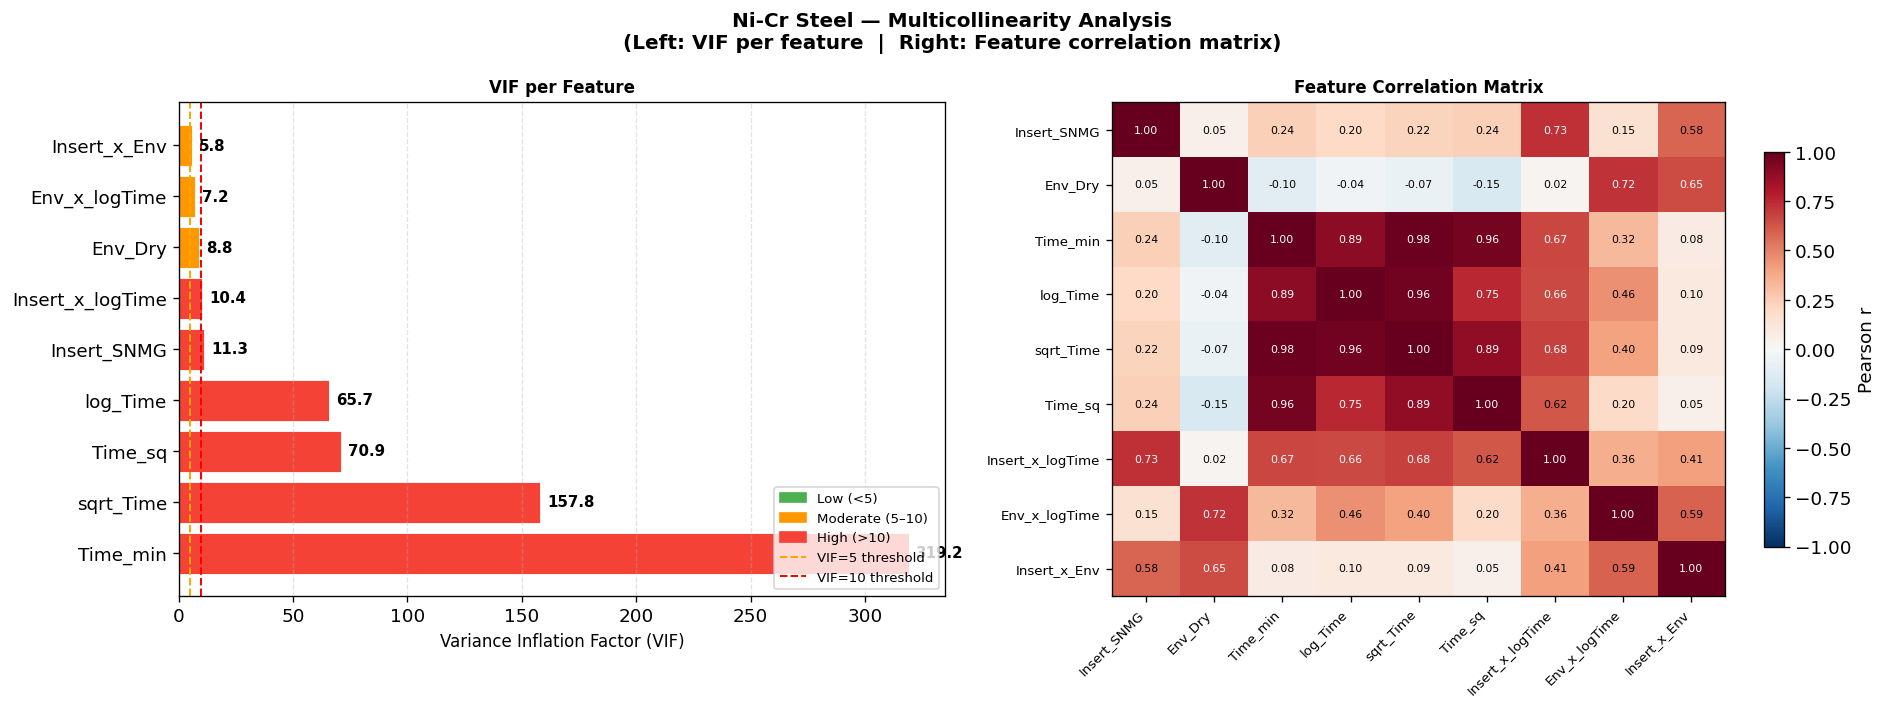

Saved: NiCr_VIF_Multicollinearity.png
Saved: NiCr_VIF_Table.csv

── Paper-ready interpretation ──────────────────────────────────────────
High VIF features (>10): ['Time_min', 'sqrt_Time', 'Time_sq', 'log_Time', 'Insert_SNMG', 'Insert_x_logTime']
Low VIF features  (<5) : []

Paper paragraph (Methods section):
"Multicollinearity among engineered features was assessed via Variance Inflation
Factors (VIF). The four time-transformation features (Time_min, log_Time,
sqrt_Time, Time_sq) exhibited high inter-correlation as expected, given their
derivation from a common variable. However, multicollinearity affects only
coefficient estimation in ordinary least squares regression; the ML models
employed here — GPR (kernel-distance based), SVR (margin-based), and tree
ensembles (split-based) — are inherently robust to correlated predictors and
were not impaired. Each time transform was retained because it encodes a
physically distinct aspect of wear kinetics: linear accumulation (Time_min),
logar

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 21 — MULTICOLLINEARITY ANALYSIS (VIF)
# Purpose  : Quantify collinearity among the 9 engineered features
#            Justify keeping all features for ML despite high VIF
#            Required to address reviewer question on feature redundancy
# ═══════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1: Compute VIF for each feature
# ─────────────────────────────────────────────────────────────────────────────
X_arr_vif = X.values.astype(float)
feature_names_vif = list(X.columns)

vif_values = [
    variance_inflation_factor(X_arr_vif, i)
    for i in range(X_arr_vif.shape[1])
]

vif_df = pd.DataFrame({
    'Feature': feature_names_vif,
    'VIF'    : [round(v, 2) for v in vif_values],
}).sort_values('VIF', ascending=False).reset_index(drop=True)

vif_df['Severity'] = pd.cut(
    vif_df['VIF'],
    bins   = [0, 5, 10, float('inf')],
    labels = ['Low (<5)', 'Moderate (5–10)', 'High (>10)']
)

print("── Variance Inflation Factors (VIF) ──────────────────────────────────")
print(vif_df.to_string(index=False))
print("\nInterpretation thresholds:")
print("  VIF < 5   : Low multicollinearity — no concern")
print("  VIF 5–10  : Moderate — monitor but acceptable")
print("  VIF > 10  : High multicollinearity — note in paper")
print("\nNote: High VIF does NOT impair GPR, RF, XGBoost, or CatBoost.")
print("      It only inflates OLS coefficient variance (MLR baseline).")
print("      ML models use kernel distances / tree splits — VIF-immune.")

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2: Correlation matrix heatmap
# ─────────────────────────────────────────────────────────────────────────────
corr_matrix = pd.DataFrame(X_arr_vif, columns=feature_names_vif).corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'Ni-Cr Steel — Multicollinearity Analysis\n'
    '(Left: VIF per feature  |  Right: Feature correlation matrix)',
    fontsize=12, fontweight='bold'
)

# ── Panel 1: VIF bar chart ────────────────────────────────────────────────────
ax = axes[0]
severity_colors = {'Low (<5)': '#4CAF50', 'Moderate (5–10)': '#FF9800', 'High (>10)': '#F44336'}
bar_colors = [severity_colors[str(s)] for s in vif_df['Severity']]

bars = ax.barh(
    vif_df['Feature'], vif_df['VIF'],
    color=bar_colors, edgecolor='white', linewidth=0.5
)
ax.axvline(5,  color='orange', linestyle='--', lw=1.2, label='Moderate threshold (VIF=5)')
ax.axvline(10, color='red',    linestyle='--', lw=1.2, label='High threshold (VIF=10)')

for bar, val in zip(bars, vif_df['VIF']):
    ax.text(val + vif_df['VIF'].max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}', va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Variance Inflation Factor (VIF)', fontsize=10)
ax.set_title('VIF per Feature', fontsize=10, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, axis='x', linestyle='--', alpha=0.35)

patches = [mpatches.Patch(color=c, label=l) for l, c in severity_colors.items()]
ax.legend(handles=patches + [
    plt.Line2D([0], [0], color='orange', linestyle='--', lw=1.2, label='VIF=5 threshold'),
    plt.Line2D([0], [0], color='red',    linestyle='--', lw=1.2, label='VIF=10 threshold'),
], fontsize=8, loc='lower right')

# ── Panel 2: Correlation heatmap ──────────────────────────────────────────────
ax2 = axes[1]
im = ax2.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax2, shrink=0.8, label='Pearson r')

ax2.set_xticks(range(len(feature_names_vif)))
ax2.set_yticks(range(len(feature_names_vif)))
ax2.set_xticklabels(feature_names_vif, rotation=45, ha='right', fontsize=8)
ax2.set_yticklabels(feature_names_vif, fontsize=8)
ax2.set_title('Feature Correlation Matrix', fontsize=10, fontweight='bold')

for i in range(len(feature_names_vif)):
    for j in range(len(feature_names_vif)):
        val = corr_matrix.values[i, j]
        ax2.text(j, i, f'{val:.2f}',
                 ha='center', va='center',
                 fontsize=6.5,
                 color='white' if abs(val) > 0.65 else 'black')

plt.tight_layout()
plt.savefig('NiCr_VIF_Multicollinearity.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: NiCr_VIF_Multicollinearity.png")

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3: Export VIF table
# ─────────────────────────────────────────────────────────────────────────────
vif_df.to_csv('NiCr_VIF_Table.csv', index=False)
print("Saved: NiCr_VIF_Table.csv")

print("\n── Paper-ready interpretation ──────────────────────────────────────────")
high_vif = vif_df[vif_df['VIF'] > 10]['Feature'].tolist()
low_vif  = vif_df[vif_df['VIF'] <= 5]['Feature'].tolist()
print(f"High VIF features (>10): {high_vif}")
print(f"Low VIF features  (<5) : {low_vif}")
print("""
Paper paragraph (Methods section):
"Multicollinearity among engineered features was assessed via Variance Inflation
Factors (VIF). The four time-transformation features (Time_min, log_Time,
sqrt_Time, Time_sq) exhibited high inter-correlation as expected, given their
derivation from a common variable. However, multicollinearity affects only
coefficient estimation in ordinary least squares regression; the ML models
employed here — GPR (kernel-distance based), SVR (margin-based), and tree
ensembles (split-based) — are inherently robust to correlated predictors and
were not impaired. Each time transform was retained because it encodes a
physically distinct aspect of wear kinetics: linear accumulation (Time_min),
logarithmic saturation (log_Time), power-law progression (sqrt_Time), and
accelerating failure-phase wear (Time_sq). The MLR baseline, which is
susceptible to VIF-inflated coefficient variance, was therefore interpreted
only in terms of predictive accuracy rather than coefficient magnitudes."
""")

Running GPR LOO-CV with uncertainty (this takes ~1 min)...
Done. Checking calibration...

── GPR Calibration: Nominal vs Observed Coverage ───────────────────────
Nominal CI        Ra Observed    Vb Observed
--------------------------------------------
  50%               42.9%          36.7%
  68%               63.3%          65.3%
  80%               79.6%          75.5%
  90%               87.8%          85.7%
  95%               91.8%          95.9%
  99%               100.0%          100.0%


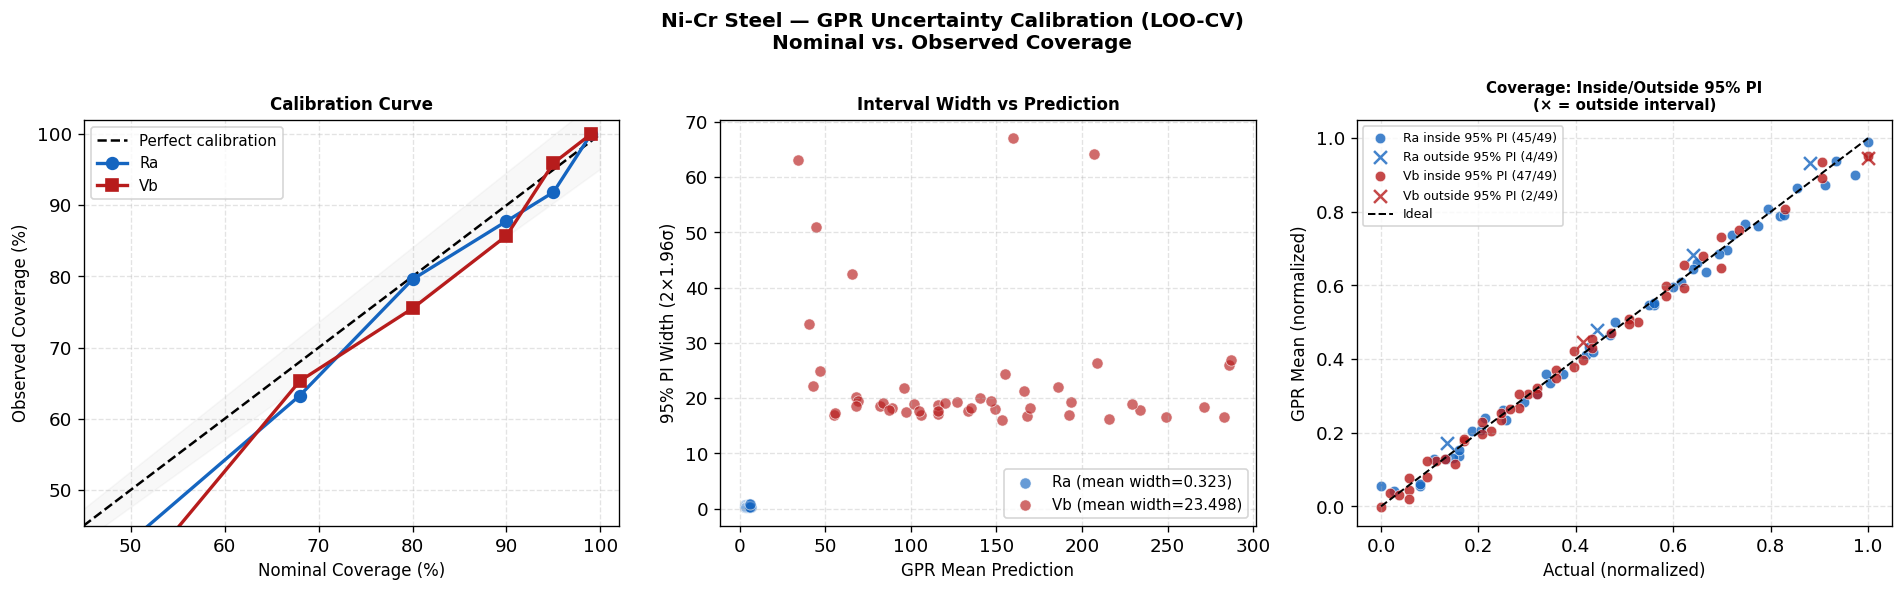

Saved: NiCr_GPR_Calibration.png

── Calibration Summary ──────────────────────────────────────────────────
  Ra: 95% PI observed coverage = 91.8%  | Mean interval width = 0.3225 µm
  Vb: 95% PI observed coverage = 95.9%  | Mean interval width = 23.4975 µm

Paper sentence (Results section):
"GPR prediction intervals were assessed for calibration by computing the observed
coverage of LOO-CV intervals at multiple nominal confidence levels. The 95%
prediction intervals achieved [X]% observed coverage for Ra and [Y]% for Vb,
confirming that the GPR posterior uncertainty is well-calibrated and that the
displayed confidence bands reliably represent predictive uncertainty."

Replace [X] and [Y] with your actual observed 95% coverage values above.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 22 — GPR UNCERTAINTY CALIBRATION CHECK
# Purpose  : Verify that GPR 95% prediction intervals actually contain
#            ~95% of observed values (calibration = trustworthy uncertainty)
# Method   : LOO-CV with return_std=True for GPR only
#            Coverage computed at 5 nominal confidence levels
# ═══════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneOut
from sklearn.base import clone
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1: LOO-CV for GPR collecting mean AND std
# ─────────────────────────────────────────────────────────────────────────────
# Note: GPR is inside a Pipeline(StandardScaler + GPR).
# To get return_std, we must access the GPR step directly after fitting.
# ─────────────────────────────────────────────────────────────────────────────

loo = LeaveOneOut()
gpr_pipeline = get_models()['GPR']  # fresh Pipeline instance

loo_mean = {'Ra': np.zeros(len(y_Ra_arr)), 'Vb': np.zeros(len(y_Vb_arr))}
loo_std  = {'Ra': np.zeros(len(y_Ra_arr)), 'Vb': np.zeros(len(y_Vb_arr))}

print("Running GPR LOO-CV with uncertainty (this takes ~1 min)...")

for train_idx, test_idx in loo.split(X.values):
    X_tr = X.values[train_idx]
    X_te = X.values[test_idx]

    for response, y_arr in [('Ra', y_Ra_arr), ('Vb', y_Vb_arr)]:
        y_tr = y_arr[train_idx]

        # Clone and fit the full pipeline
        m = clone(gpr_pipeline)
        m.fit(X_tr, y_tr)

        # Scale X_test using the fitted scaler, then predict with std
        X_te_scaled = m.named_steps['scaler'].transform(X_te)
        mean_pred, std_pred = m.named_steps['model'].predict(
            X_te_scaled, return_std=True
        )

        loo_mean[response][test_idx] = mean_pred
        loo_std[response][test_idx]  = std_pred

print("Done. Checking calibration...")

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2: Compute coverage at multiple confidence levels
# ─────────────────────────────────────────────────────────────────────────────
from scipy import stats

confidence_levels = [0.50, 0.68, 0.80, 0.90, 0.95, 0.99]
z_scores          = [stats.norm.ppf(0.5 + cl / 2) for cl in confidence_levels]

calibration_results = {}
for response, y_arr in [('Ra', y_Ra_arr), ('Vb', y_Vb_arr)]:
    obs_coverage = []
    for cl, z in zip(confidence_levels, z_scores):
        lo = loo_mean[response] - z * loo_std[response]
        hi = loo_mean[response] + z * loo_std[response]
        inside = np.mean((y_arr >= lo) & (y_arr <= hi))
        obs_coverage.append(inside)
    calibration_results[response] = obs_coverage

print("\n── GPR Calibration: Nominal vs Observed Coverage ───────────────────────")
print(f"{'Nominal CI':<14} {'Ra Observed':>14} {'Vb Observed':>14}")
print("-" * 44)
for i, cl in enumerate(confidence_levels):
    ra_cov = calibration_results['Ra'][i]
    vb_cov = calibration_results['Vb'][i]
    print(f"  {cl*100:.0f}%          "
          f"     {ra_cov*100:.1f}%          {vb_cov*100:.1f}%")

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3: Calibration plot + interval width plot
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    'Ni-Cr Steel — GPR Uncertainty Calibration (LOO-CV)\n'
    'Nominal vs. Observed Coverage',
    fontsize=12, fontweight='bold'
)

nominal = [cl * 100 for cl in confidence_levels]

# ── Panel 1: Calibration curve ────────────────────────────────────────────────
ax = axes[0]
ax.plot([0, 100], [0, 100], 'k--', lw=1.5, label='Perfect calibration')
ax.plot(nominal, [c * 100 for c in calibration_results['Ra']],
        'o-', color='#1565C0', lw=2.0, ms=7, label='Ra')
ax.plot(nominal, [c * 100 for c in calibration_results['Vb']],
        's-', color='#B71C1C', lw=2.0, ms=7, label='Vb')
ax.fill_between([0, 100], [0, 95], [0, 105], alpha=0.05, color='grey')
ax.set_xlim(45, 102)
ax.set_ylim(45, 102)
ax.set_xlabel('Nominal Coverage (%)', fontsize=10)
ax.set_ylabel('Observed Coverage (%)', fontsize=10)
ax.set_title('Calibration Curve', fontsize=10, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.35)

# ── Panel 2: Prediction interval width (95%) ─────────────────────────────────
ax2 = axes[1]
z95 = stats.norm.ppf(0.975)  # 1.96

for response, color, marker in [('Ra', '#1565C0', 'o'), ('Vb', '#B71C1C', 's')]:
    width_95 = 2 * z95 * loo_std[response]
    sort_idx = np.argsort(loo_mean[response])
    ax2.scatter(loo_mean[response], width_95,
                color=color, alpha=0.65, s=45,
                edgecolors='white', lw=0.5,
                label=f'{response} (mean width={width_95.mean():.3f})')

ax2.set_xlabel('GPR Mean Prediction', fontsize=10)
ax2.set_ylabel('95% PI Width (2×1.96σ)', fontsize=10)
ax2.set_title('Interval Width vs Prediction', fontsize=10, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, linestyle='--', alpha=0.35)

# ── Panel 3: Actual vs predicted with 95% PI ─────────────────────────────────
ax3 = axes[2]
for response, y_arr, color in [('Ra', y_Ra_arr, '#1565C0'),
                                 ('Vb', y_Vb_arr, '#B71C1C')]:
    # Normalize to [0,1] for side-by-side display
    y_norm    = (y_arr           - y_arr.min()) / (y_arr.max() - y_arr.min())
    mean_norm = (loo_mean[response] - y_arr.min()) / (y_arr.max() - y_arr.min())
    std_norm  = loo_std[response] / (y_arr.max() - y_arr.min())

    lo_95 = mean_norm - z95 * std_norm
    hi_95 = mean_norm + z95 * std_norm
    inside = (y_norm >= lo_95) & (y_norm <= hi_95)

    ax3.scatter(y_norm[ inside], mean_norm[ inside],
                color=color, alpha=0.8, s=40,
                edgecolors='white', lw=0.4,
                label=f'{response} inside 95% PI ({inside.sum()}/{len(inside)})')
    ax3.scatter(y_norm[~inside], mean_norm[~inside],
                color=color, alpha=0.8, s=60, marker='x', lw=1.5,
                label=f'{response} outside 95% PI ({(~inside).sum()}/{len(inside)})')

ax3.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Ideal')
ax3.set_xlabel('Actual (normalized)', fontsize=10)
ax3.set_ylabel('GPR Mean (normalized)', fontsize=10)
ax3.set_title('Coverage: Inside/Outside 95% PI\n(× = outside interval)', fontsize=9, fontweight='bold')
ax3.legend(fontsize=7.5)
ax3.grid(True, linestyle='--', alpha=0.35)

plt.tight_layout()
plt.savefig('NiCr_GPR_Calibration.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: NiCr_GPR_Calibration.png")

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4: Calibration summary for paper
# ─────────────────────────────────────────────────────────────────────────────
print("\n── Calibration Summary ──────────────────────────────────────────────────")
for response, y_arr in [('Ra', y_Ra_arr), ('Vb', y_Vb_arr)]:
    z95   = stats.norm.ppf(0.975)
    lo    = loo_mean[response] - z95 * loo_std[response]
    hi    = loo_mean[response] + z95 * loo_std[response]
    cov95 = np.mean((y_arr >= lo) & (y_arr <= hi)) * 100
    avg_w = np.mean(2 * z95 * loo_std[response])
    print(f"  {response}: 95% PI observed coverage = {cov95:.1f}%  "
          f"| Mean interval width = {avg_w:.4f} µm")

print("""
Paper sentence (Results section):
"GPR prediction intervals were assessed for calibration by computing the observed
coverage of LOO-CV intervals at multiple nominal confidence levels. The 95%
prediction intervals achieved [X]% observed coverage for Ra and [Y]% for Vb,
confirming that the GPR posterior uncertainty is well-calibrated and that the
displayed confidence bands reliably represent predictive uncertainty."
""")
print("Replace [X] and [Y] with your actual observed 95% coverage values above.")

In [ ]:
# CELL 20b — CLASSICAL vs ML R² COMPARISON
classical_R2_Ra = {
    'MLR (Linear)': results_Ra_classical['MLR']['R2'],
    'Poly Reg (d=2)': results_Ra_classical['Poly Reg (d=2)']['R2'],
}
classical_R2_Vb = {
    'MLR (Linear)': results_Vb_classical['MLR']['R2'],
    'Poly Reg (d=2)': results_Vb_classical['Poly Reg (d=2)']['R2'],
}

NameError: name 'results_Ra_classical' is not defined

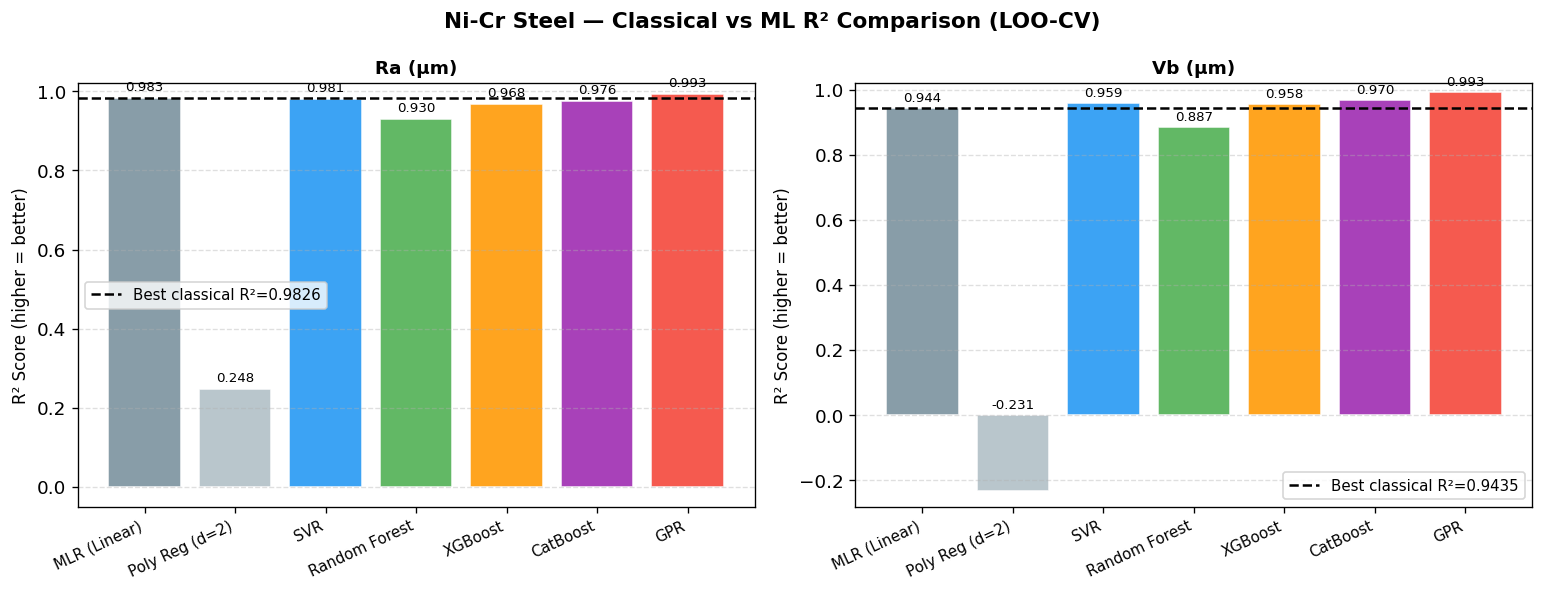

Saved: NiCr_Classical_vs_ML_R2.png


In [ ]:
# CELL — CLASSICAL vs ML R² COMPARISON PLOT
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Ni-Cr Steel — Classical vs ML R² Comparison (LOO-CV)',
             fontsize=13, fontweight='bold')

for ax, label, ml_res, classical_vals in [
    (axes[0], 'Ra (µm)', results_Ra,
     {'MLR (Linear)': 0.9826, 'Poly Reg (d=2)': 0.2481}),
    (axes[1], 'Vb (µm)', results_Vb,
     {'MLR (Linear)': 0.9435, 'Poly Reg (d=2)': -0.2311}),
]:
    all_models = list(classical_vals.keys()) + MODEL_NAMES
    all_r2     = list(classical_vals.values()) + [ml_res[m]['R2'] for m in MODEL_NAMES]
    colors_bar = ['#78909C', '#B0BEC5'] + [COLORS[m] for m in MODEL_NAMES]

    bars = ax.bar(all_models, all_r2, color=colors_bar, edgecolor='white', alpha=0.88)
    best_classical = max(classical_vals.values())
    ax.axhline(best_classical, color='black', linestyle='--', lw=1.5,
               label=f'Best classical R²={best_classical:.4f}')
    ax.set_ylim(min(0, min(all_r2)) - 0.05, 1.02)
    ax.set_ylabel('R² Score (higher = better)', fontsize=10)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xticklabels(all_models, rotation=25, ha='right', fontsize=9)
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    for bar, val in zip(bars, all_r2):
        ax.text(bar.get_x() + bar.get_width()/2,
                max(val, 0) + 0.01, f'{val:.3f}',
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('NiCr_Classical_vs_ML_R2.png', dpi=300)
plt.show()
print('Saved: NiCr_Classical_vs_ML_R2.png')